(mmm_causal_identification)=

# Introduction to Understanding Causal Relationships in Media Mix Modeling

Causal identification is about figuring out if we can prove a cause-and-effect relationship using the data we have and our assumptions. This process helps us establish clear links between different factors instead of looking at their correlations. It is essential when working with observational data, which can be affected by hidden factors and biases that make it hard to see true causal relationships.

> Note: Inspired by the notebook from [Bridging Causal Thinking and Media Mix Models: Carlos Trujillo & Ben Vincent](https://colab.research.google.com/drive/1r5pi9Lh_A6h_CKQFEjyn-7iykL8x-X_H#scrollTo=DRFEJyK1VCi3).

## Why Is Understanding Causal Relationships Important in Regressions?

In regression models, we often aim to estimate how one or more factors affect an outcome. However, if we don't consider causality carefully, our estimates can be biased due to:

1. **Confounding Bias**: This happens when a hidden factor influences both the predictor and the outcome, leading to misleading connections.
2. **Selection Bias**: When we use non-random samples, this can distort the estimated relationships.
3. **Overcontrol**: Adjusting for variables that are influenced by the treatment can lead to incorrect estimates of causal effects.

Causal identification helps us adjust the right variables in the regression to isolate the true effect by addressing confounders and avoiding unnecessary adjustments. Without it, we can run into several problems:

- **Bias in Estimates**: Our understanding of effect size and direction might be wrong, which can lead to poor decisions.
- **Spurious Correlations**: We might misinterpret coincidental relationships as causal.
- **Inefficient Models**: Including irrelevant variables or missing important confounders can weaken the model’s accuracy and clarity.

In media mix modeling (MMM), where businesses allocate budgets across different channels to maximize returns, these issues can lead to poor resource allocation, wasted money, or misattributing success to ineffective strategies.

## Key Concepts in This Notebook

This notebook covers key ideas in causal inference, including:

- **Causal Directed Acyclic Graphs (DAGs)**: These are visual tools that show the assumed causal relationships in the data.
- **Backdoor Criterion**: This rule helps identify which variables block paths that create misleading connections between the treatment and outcome.
- **Minimal Adjustment Set**: This is the smallest group of factors needed to meet the backdoor criterion, ensuring accurate causal estimates.

These tools help us understand causal inference more clearly and give us solid guidelines for choosing variables in media mix models.

By the end of this notebook, you will learn how to use `pymc-marketing` alongside causal thinking principles for effective media mix modeling. 

Let’s start by importing the necessary libraries!

In [1]:
# avoid all warnings types
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import seaborn as sns
from arviz_stats import bayesian_r2
from graphviz import Digraph
from IPython.display import SVG, display
from pymc_extras.prior import Prior

from pymc_marketing.hsgp_kwargs import CovFunc, HSGPKwargs
from pymc_marketing.mmm import MMM, GeometricAdstock, MichaelisMentenSaturation
from pymc_marketing.mmm.transformers import geometric_adstock, michaelis_menten

warnings.filterwarnings("ignore")
az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams.update({"figure.constrained_layout.use": True})
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
# We use a fixed random seed to ensure that our results are reproducible
seed = sum(map(ord, "Causal MMM"))
rng = np.random.default_rng(seed)

## Business problem

Imagine you run a retail company that advertises its products. You've been in business for a while and have noticed steady sales growth. During holidays, sales increase even more. However, you're not the only one advertising; a competitor is also promoting their products, likely with discounts or special offers.

Let's explore how different factors relate to each other:

1. **Christmas (C)**: The holiday season boosts consumer interest, leading to more ad views (X1 and X2) and directly increasing your sales (T).
2. **Marketing Channels (X1, X2)**:
   - **X1**: Social media ads, like those on Facebook or TikTok.
   - **X2**: Search engine ads, which can enhance the impact of social media ads (these channels work well together).
3. **Target (T)**: Your goal is to maximize sales revenue.
4. **Unseen Factors**:
   - **Competitor Offers (I)**: Your competitor may run aggressive holiday discounts, which could lessen the impact of your search ads (X2) and reduce your sales (T).
   - **Market Growth (G)**: Economic growth during the holiday season might boost sales (T) regardless of your advertising efforts.

### Visualizing Relationships with a DAG

We can illustrate these ideas using a Directed Acyclic Graph (DAG).

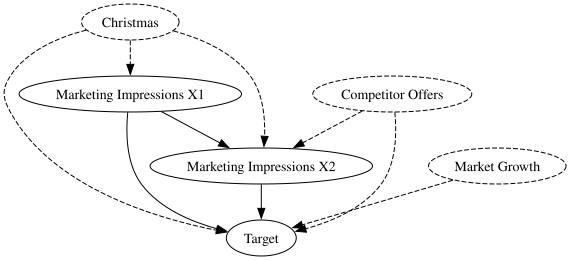

In [3]:
# Initialize a directed graph
dot = Digraph()

# Add nodes
dot.node("C", "Christmas", style="dashed")
dot.node("X1", "Marketing Impressions X1")
dot.node("X2", "Marketing Impressions X2")
dot.node("I", "Competitor Offers", style="dashed")
dot.node("G", "Market Growth", style="dashed")
dot.node("T", "Target")

# Add edges to represent the relationships
dot.edge("C", "X1", style="dashed")
dot.edge("C", "X2", style="dashed")
dot.edge("I", "X2", style="dashed")
dot.edge("X1", "X2")

## Variables that affect the target
dot.edge("C", "T", style="dashed")
dot.edge("X1", "T")
dot.edge("X2", "T")
dot.edge("I", "T", style="dashed")
dot.edge("G", "T", style="dashed")

# Render the graph to SVG and display it inline
svg_str = dot.pipe(format="svg")
display(SVG(svg_str))

#### Observed Factors:
1. **Marketing Impressions X1 and X2**: Two channels (search ads and social ads) that can affect sales (T). They can also impact each other.
2. **Target (T)**: The key metric you want to improve, like sales revenue.

#### Unseen Factors (Dashed Elements):
1. **Christmas (C)**: A seasonal event that influences both marketing impressions (X1, X2) and sales (T).
2. **Competitor Offers (I)**: Actions by competitors, such as discounts, which can influence marketing channels and sales.
3. **Market Growth (G)**: Broader economic trends that affect sales.

> Note: Dashed elements are not possible to intervene, on the other hand, solid elements are possible to intervene.

#### Key Relationships:
- Christmas (C) boosts both marketing impressions (X1, X2) and directly increases sales (T) during the holiday season.
- Marketing impressions (X1, X2) affect sales (T) through your advertising efforts. X1 can help X2 (e.g., social ads support search ads).
- Competitor Offers (I) and Market Growth (G) impact the marketing channels and sales, which can confuse the understanding of cause and effect.

We now need to define how these relationships work and create a model to generate data that reflects these assumptions. This way, we can see how well we can identify causal relationships using the data we gather.

In [4]:
# date range
min_date = pd.to_datetime("2022-01-01")
max_date = pd.to_datetime("2024-11-06")
date_range = pd.date_range(start=min_date, end=max_date, freq="D")

df = pd.DataFrame(data={"date_week": date_range}).assign(
    year=lambda x: x["date_week"].dt.year,
    month=lambda x: x["date_week"].dt.month,
    dayofyear=lambda x: x["date_week"].dt.dayofyear,
)

n = df.shape[0]
print(f"Number of observations: {n}")

Number of observations: 1041


We set a date range between January 2022 and November 2024, at a daily frequency.

### Generating the Market Growth (Trend)
Next, we generate the data for **market growth**. We assume the market growth follows a power-law trend, meaning that growth accelerates over time rather than remaining constant. This can be mathematically defined as:

$$
MG_{t} = (t + \text{baseline})^{\text{exponent}} - 1
$$

Where:
- $t$: The time index, representing days since the start of the date range.
- $baseline$: A constant added to $t$ to shift the starting point of the trend. This value affects the initial level of market growth. The starting value of the function will be $(baseline)^{exponent} - 1$, not 0.
- $exponent$: The power to which the time index is raised, determining the rate at which the trend accelerates over time.

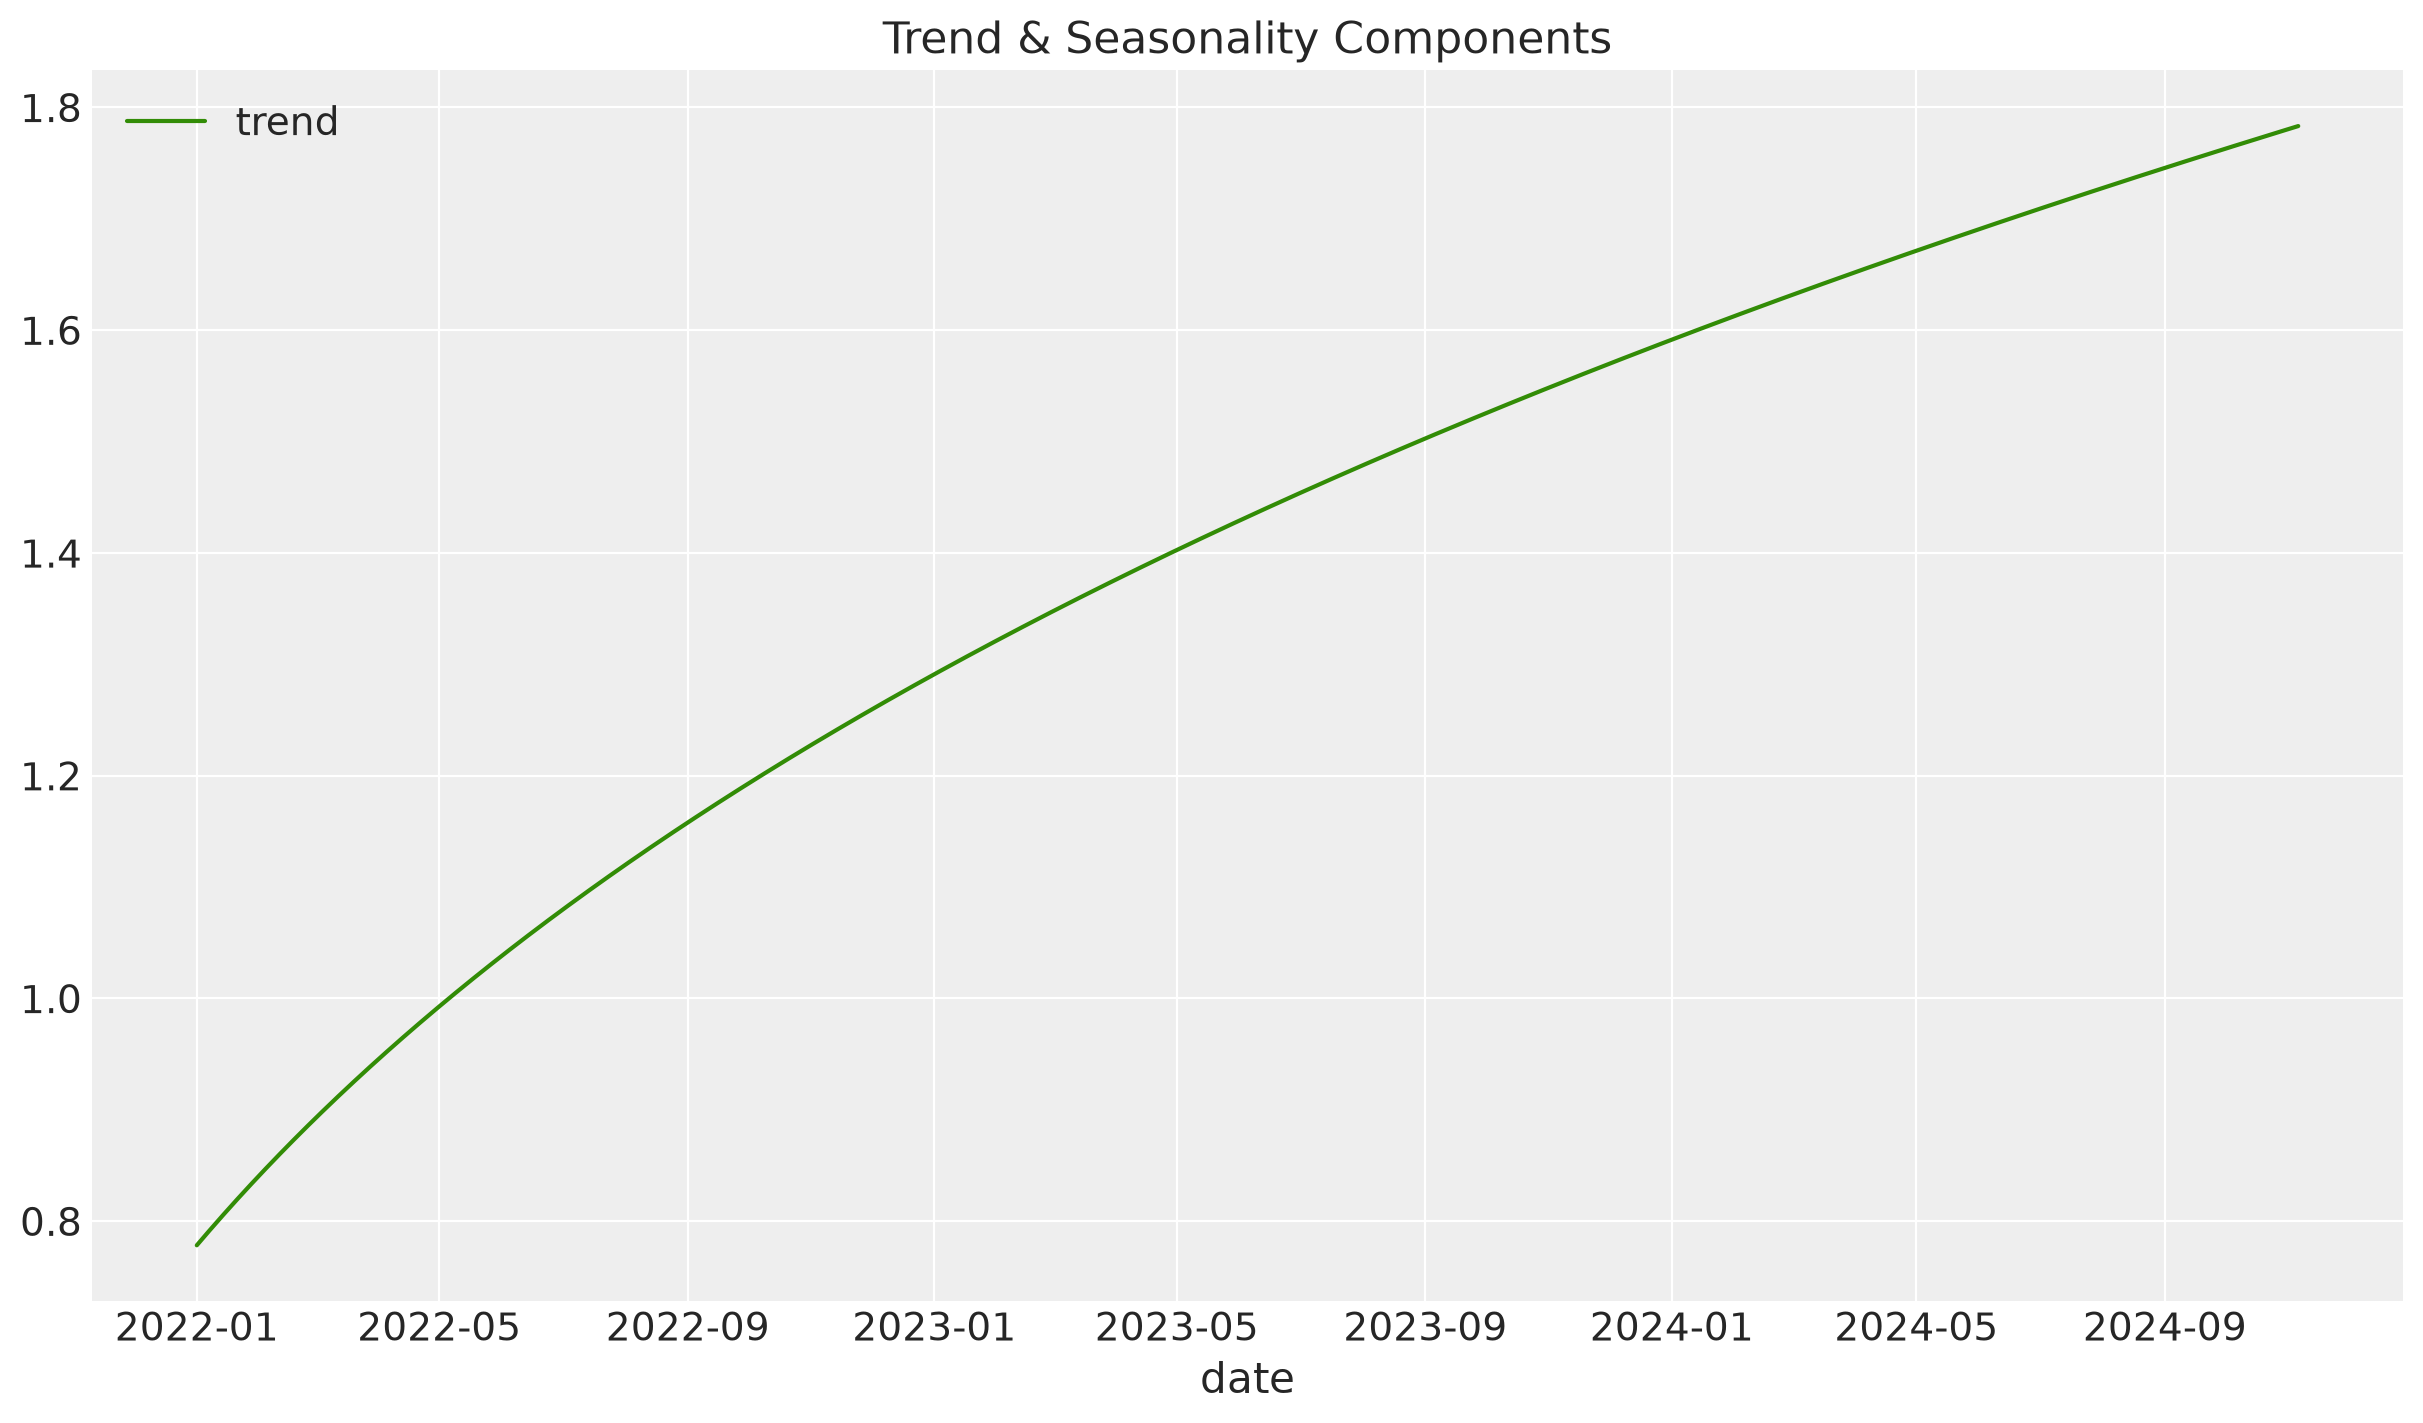

In [5]:
df["market_growth"] = (np.linspace(start=0.0, stop=50, num=n) + 10) ** (1 / 4) - 1

fig, ax = plt.subplots()
sns.lineplot(
    x="date_week", y="market_growth", color="C2", label="trend", data=df, ax=ax
)
ax.legend(loc="upper left")
ax.set(title="Trend & Seasonality Components", xlabel="date", ylabel=None);

### Generating the Holiday Effect

In this section, we simulate the effect of holidays on the market growth trend. Certain holidays, like Christmas, can have a significant impact on consumer behavior, leading to seasonal spikes in sales. To capture these effects, we introduce a holiday signal based on Gaussian (normal) distributions centered around specific holiday dates.

The function used to model the holiday effect is defined as follows:

$$
H_{t} = \exp\left(-0.5 \left(\frac{\Delta t}{\sigma}\right)^2\right)
$$

Where:
- $\Delta t$ is the time difference (in days) between the current date and the holiday date.
- $\sigma$ is the standard deviation that controls the spread of the effect around the holiday date.

For each holiday, we calculate the holiday signal across the date range and add a **holiday contribution** by scaling the signal with a holiday-specific coefficient. This approach models seasonal holiday spikes using Gaussian functions, which capture the transient increase in market activity around holidays, and their respective decay over time.

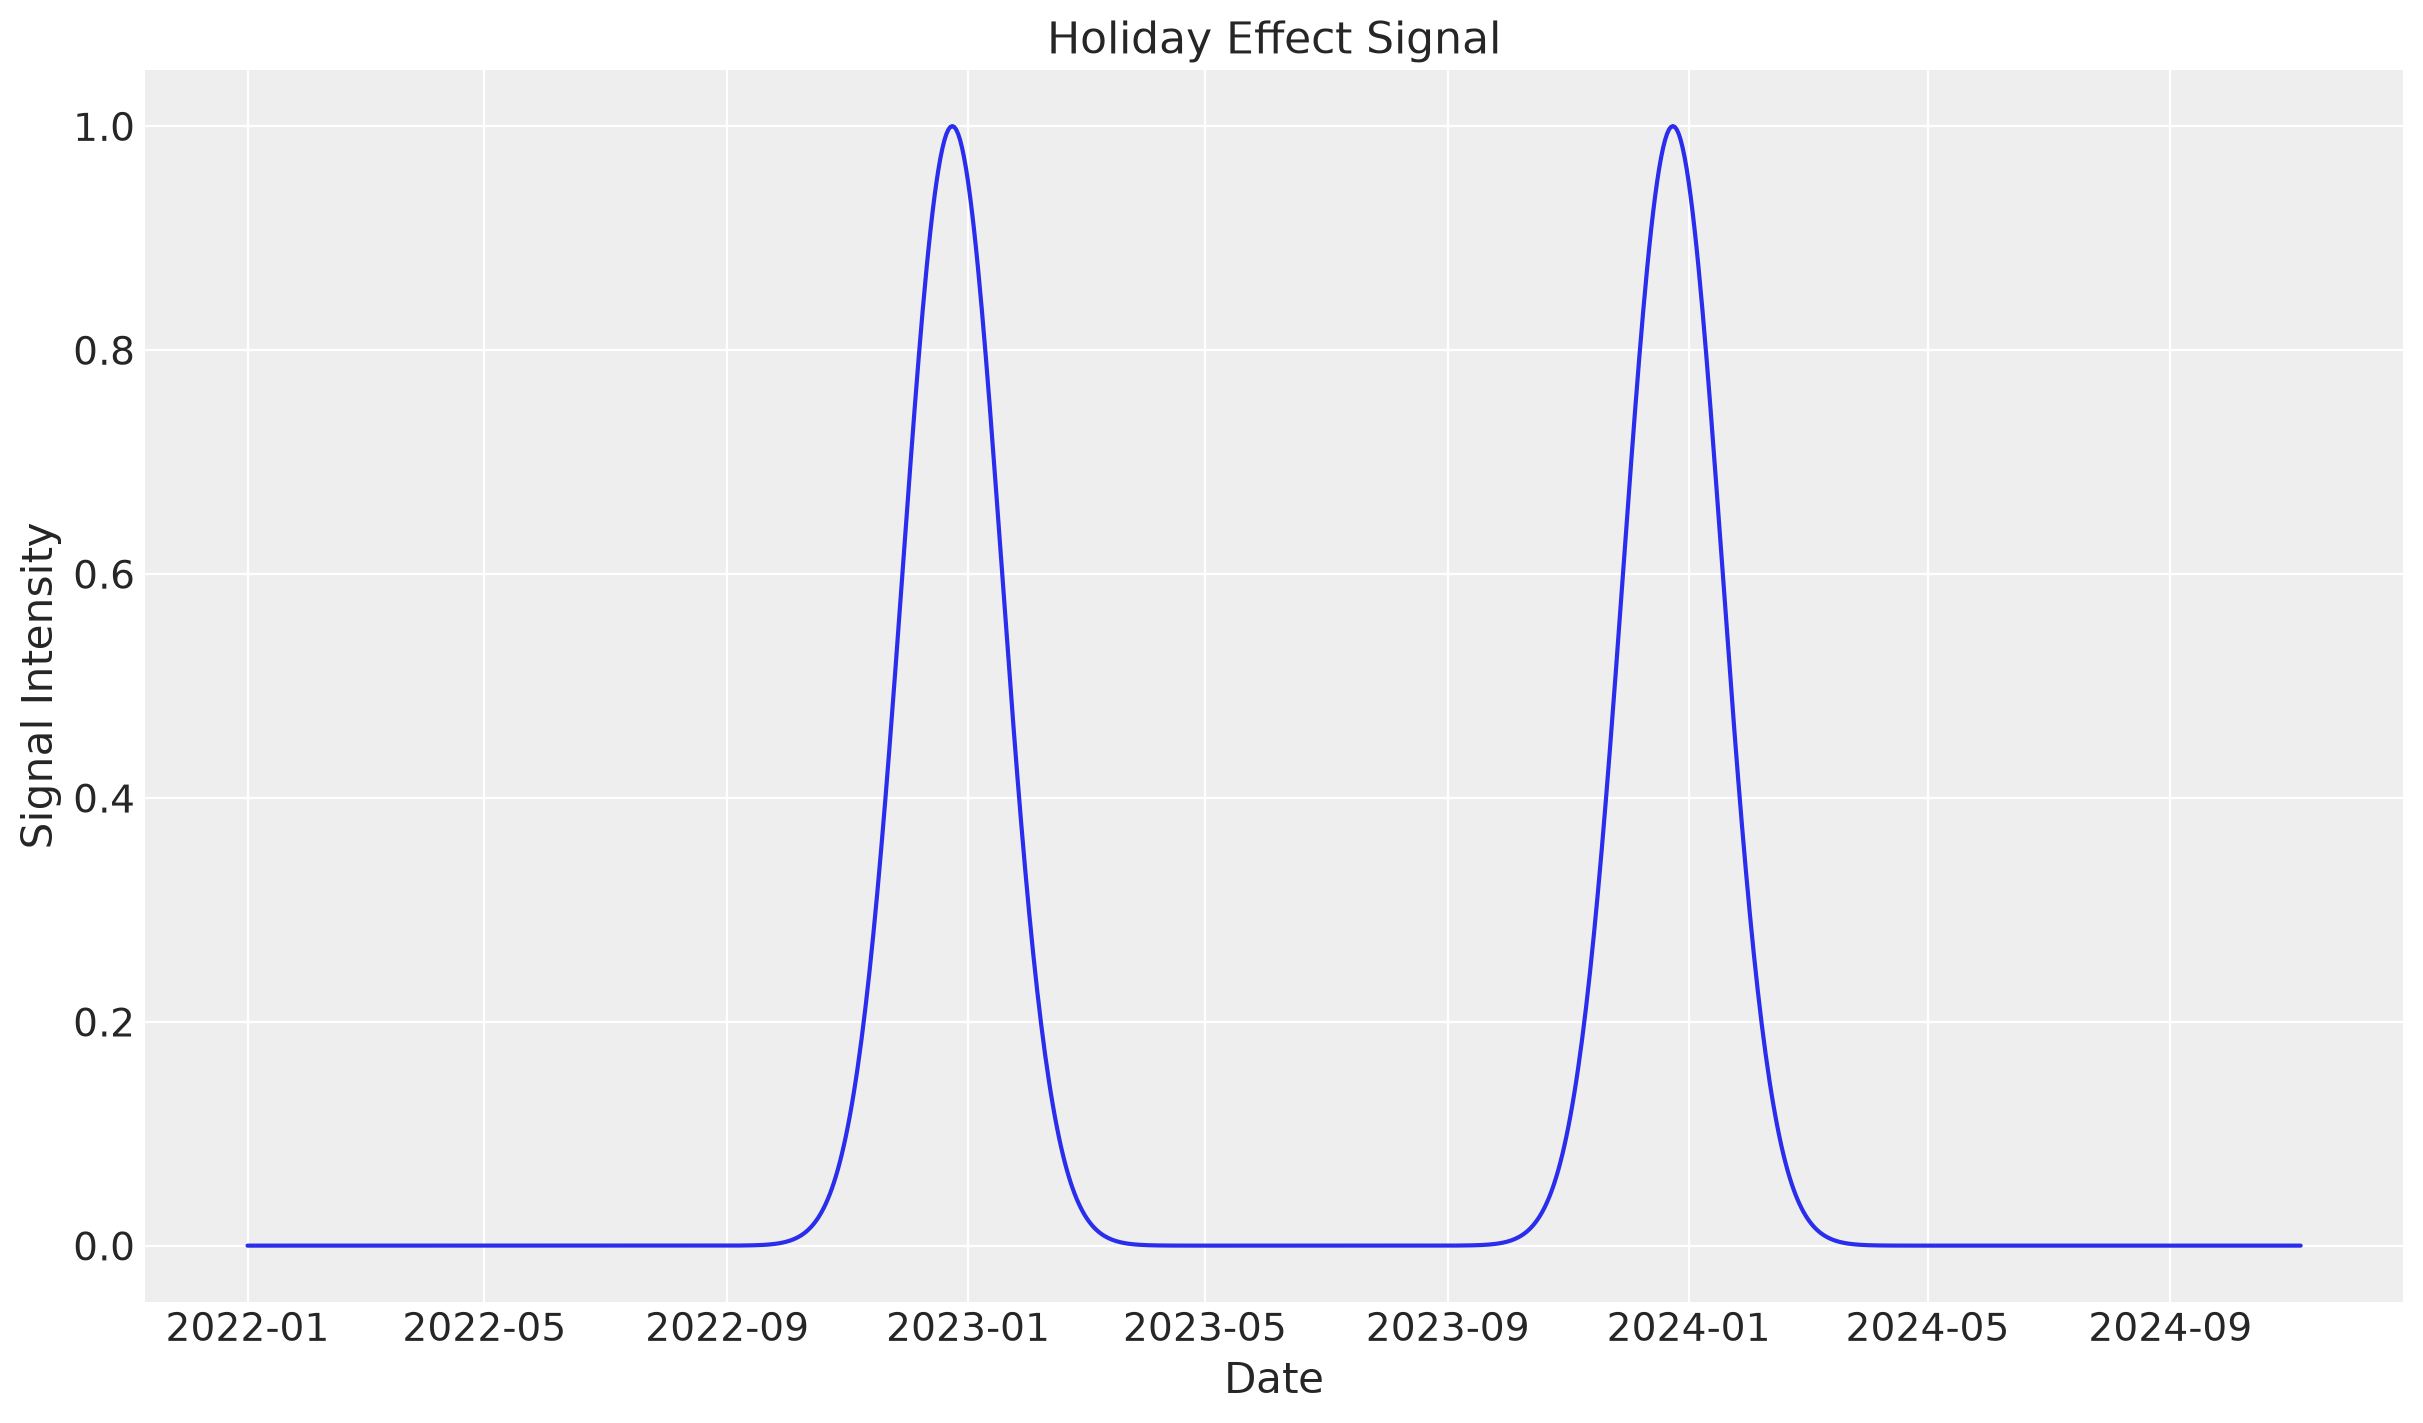

In [6]:
holiday_dates = ["24-12"]  # List of holidays as month-day strings
std_devs = [25]  # List of standard deviations for each holiday
holidays_coefficients = [2]

# Initialize the holiday effect array
holiday_signal = np.zeros(len(date_range))
holiday_contributions = np.zeros(len(date_range))

# Generate holiday signals
for holiday, std_dev, holiday_coef in zip(
    holiday_dates, std_devs, holidays_coefficients, strict=False
):
    # Find all occurrences of the holiday in the date range
    holiday_occurrences = date_range[date_range.strftime("%d-%m") == holiday]

    for occurrence in holiday_occurrences:
        # Calculate the time difference in days
        time_diff = (date_range - occurrence).days

        # Generate the Gaussian basis for the holiday
        _holiday_signal = np.exp(-0.5 * (time_diff / std_dev) ** 2)

        # Add the holiday signal to the holiday effect
        holiday_signal += _holiday_signal

        holiday_contributions += _holiday_signal * holiday_coef

df["holiday_signal"] = holiday_signal
df["holiday_contributions"] = holiday_contributions

# Plot the holiday effect
fig, ax = plt.subplots()
sns.lineplot(x=date_range, y=holiday_signal, ax=ax)
ax.set(title="Holiday Effect Signal", xlabel="Date", ylabel="Signal Intensity")
plt.show()

### Modeling Competitor Offers

To simulate the impact of competitor offers on market growth.

$$
C_{t} = -A \cdot \cos(\omega \cdot t) + C
$$

Where:
- $A$: The **amplitude** of the oscillation, representing the maximum deviation from the center. In this context, it controls the intensity of the competitor offers.
- $C$: The **center of oscillation**, setting the average level around which competitor offers fluctuate.
- $\omega$: The **angular frequency**, which determines the frequency of the oscillations. It’s calculated as: $\omega = \frac{\pi}{\frac{n}{2}}$ where $n$ is the total number of data points. This ensures a complete cycle within the specified range.

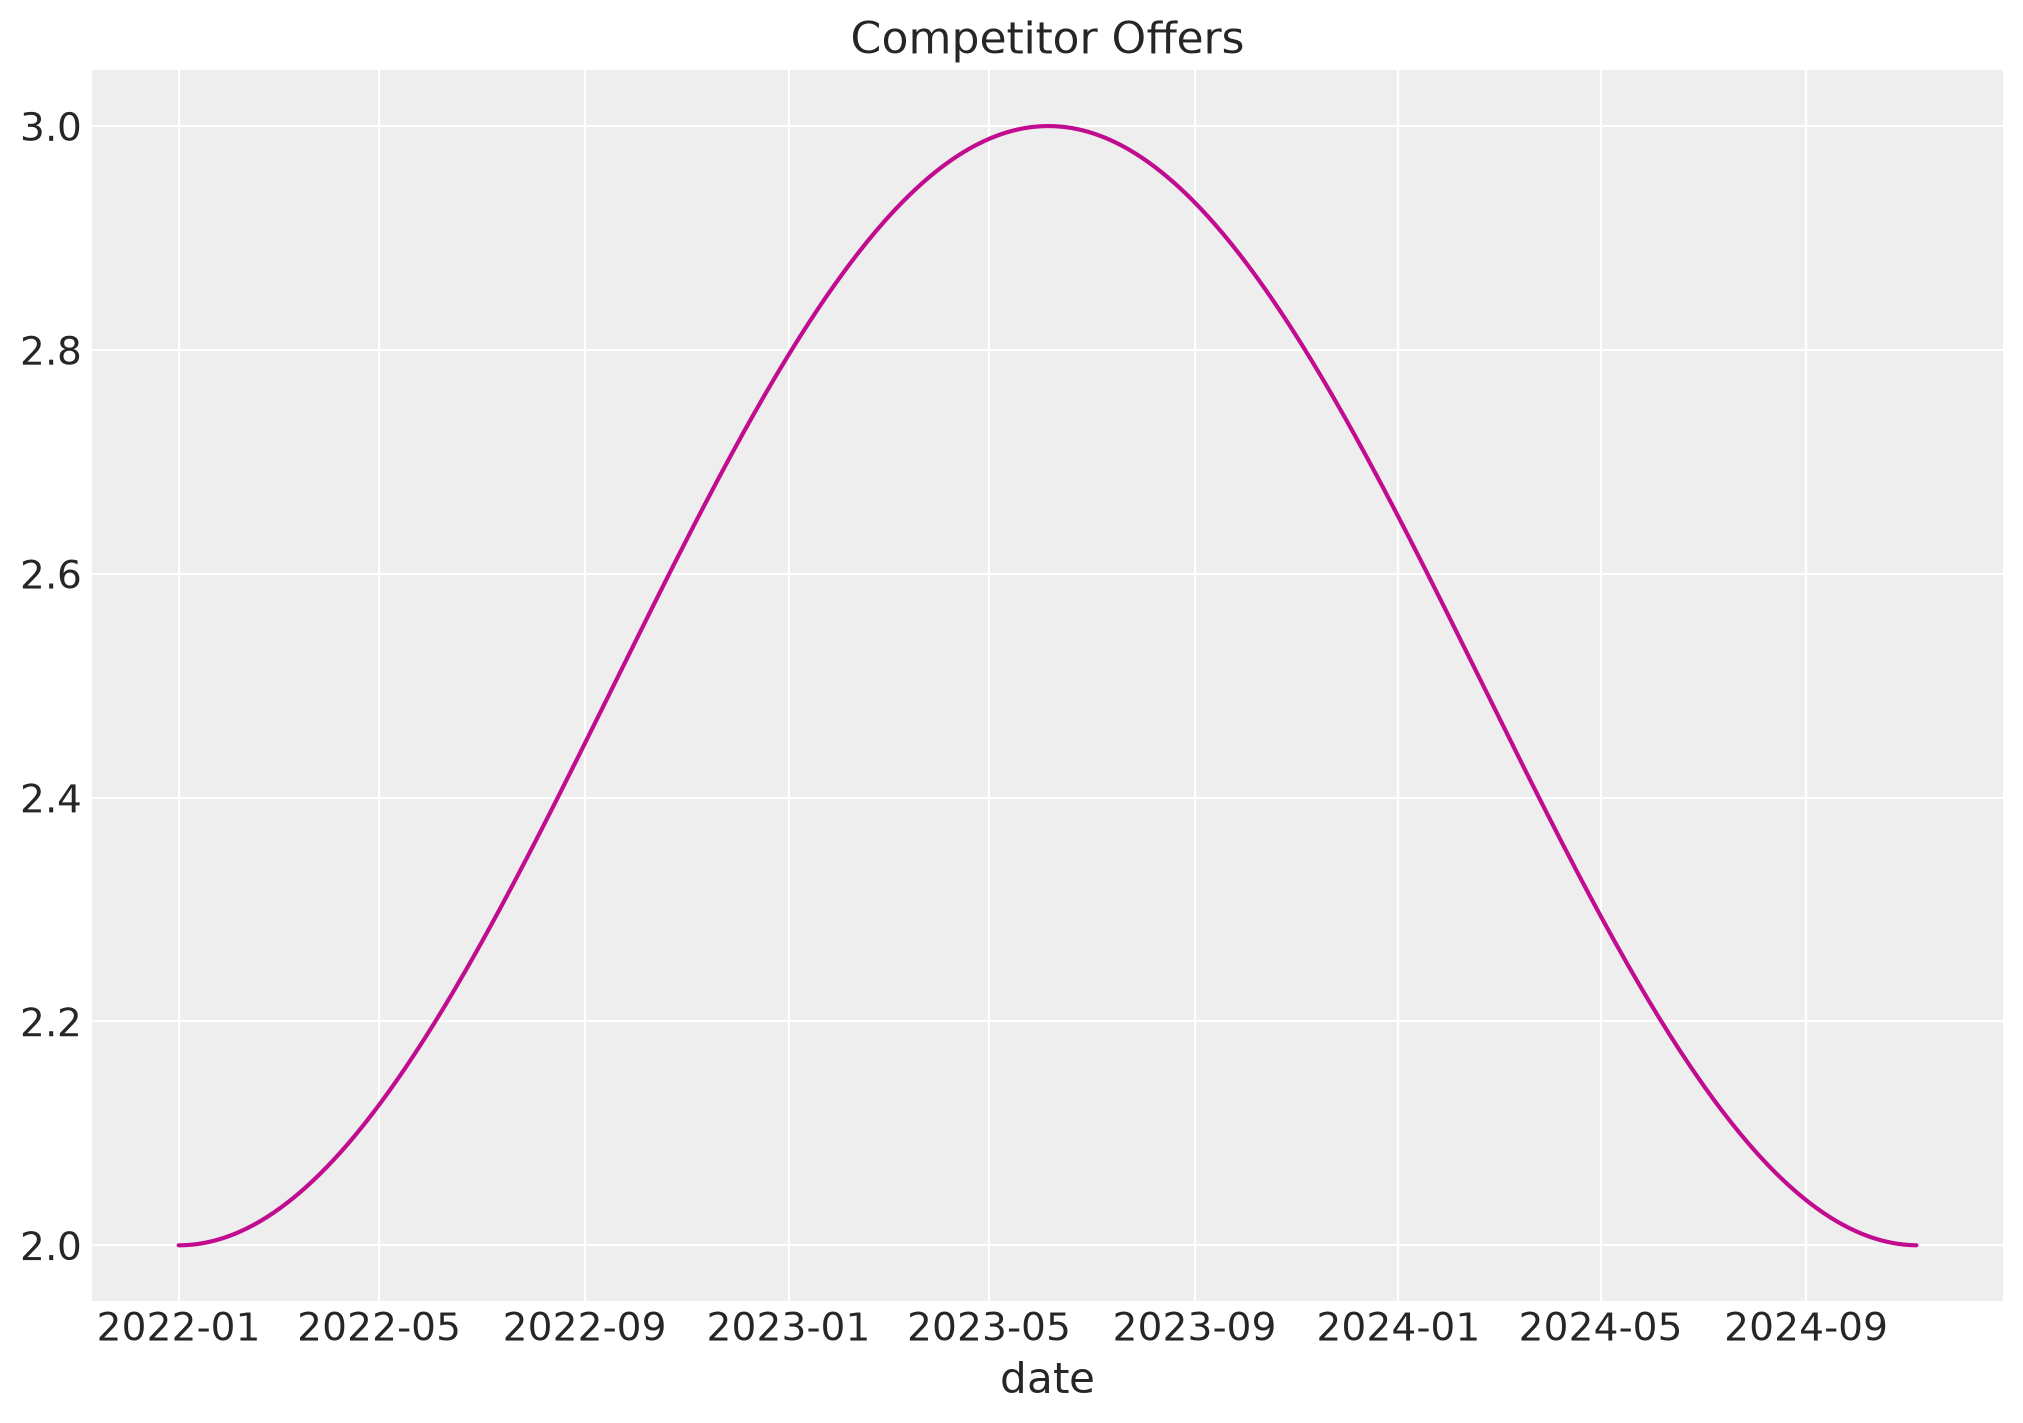

In [7]:
A = 0.5  # Amplitude
C = 2.5  # Center of the oscillation
omega = np.pi / (n / 2)

df["competitor_offers"] = -A * np.cos(omega * df.index) + C

# plot the competition price and competitor_offers
fig, ax = plt.subplots(
    nrows=1, ncols=1, figsize=(10, 7), sharex=True, layout="constrained"
)
sns.lineplot(x="date_week", y="competitor_offers", data=df, color="C3", ax=ax)
ax.set(title="Competitor Offers", xlabel="date", ylabel=None);

With this form, we simulate a world where competitors offers increase during the initial days of the year, and then decrease towards the end of the year.

### Modeling Marketing Channels

In this section, we simulate two marketing channels, $x1$ and $x2$, which represent different advertising channels (e.g., Search ads and Social media campaigns). Each channel's behavior is influenced by random variability and confounding effects from seasonal holidays and competitor actions. Here’s how we model each channel mathematically:

**Channel $x1$**:
As mentioned before, we generate $x1$ which is affected by the holiday signal, we could define it as:

$$
I_{x1_t} = S_{x1_t} + H_{t} \times \alpha_{x1}
$$

**Channel $x2$**:
On the other hand, we generate $x2$ which is affected by the holiday signal, the influence of $x1$ and the competitor offers. We could define it as:

$$
I_{x2_t} = S_{x2_t} + H_{t} \times \alpha_{x2} + (I_{x1_t} \times \alpha_{x1_x2}) + (C_{t} \times \alpha_{x2})
$$

### Interpretation

These equations allow us to capture the complex dynamics influencing each marketing channel:
- **Holiday Effects** increase channel activity around specific dates, simulating seasonal spikes.
- **Cross-channel Influences** introduce interdependencies, modeling how one channel's success can amplify another’s.
- **Competitor Effects** introduce fluctuations due to external factors, showing how competitive pressure can decrease engagement or effectiveness.

This approach reflects real-world conditions, where marketing channels are not isolated but affected by seasonal trends, competitor actions, and synergies across different channels.


In [8]:
x1 = pz.Normal(mu=5, sigma=3).rvs(n, random_state=rng)
cofounder_effect_holiday_x1 = 2.5
x1_conv = np.convolve(x1, np.ones(14) / 14, mode="same")
# Replace first and last 14 values with mean + noise
noise = pz.Normal(mu=0, sigma=0.1).rvs(28, random_state=rng)
x1_conv[:14] = x1_conv.mean() + noise[:14]
x1_conv[-14:] = x1_conv.mean() + noise[14:]
df["x1"] = x1_conv + (holiday_signal * cofounder_effect_holiday_x1)

x2 = pz.Normal(mu=5, sigma=2).rvs(n, random_state=rng)
cofounder_effect_holiday_x2 = 2.2
cofounder_effect_x1_x2 = 1.3
cofounder_effect_competitor_offers_x2 = -0.7
x2_conv = np.convolve(x2, np.ones(18) / 12, mode="same")
# Replace first and last 14 values with mean + noise
noise = pz.Normal(mu=0, sigma=0.1).rvs(28, random_state=rng)
x2_conv[:14] = x2_conv.mean() + noise[:14]
x2_conv[-14:] = x2_conv.mean() + noise[14:]
df["x2"] = (
    x2_conv
    + (holiday_signal * cofounder_effect_holiday_x2)
    + (df["x1"] * cofounder_effect_x1_x2)
    + (df["competitor_offers"] * cofounder_effect_competitor_offers_x2)
)

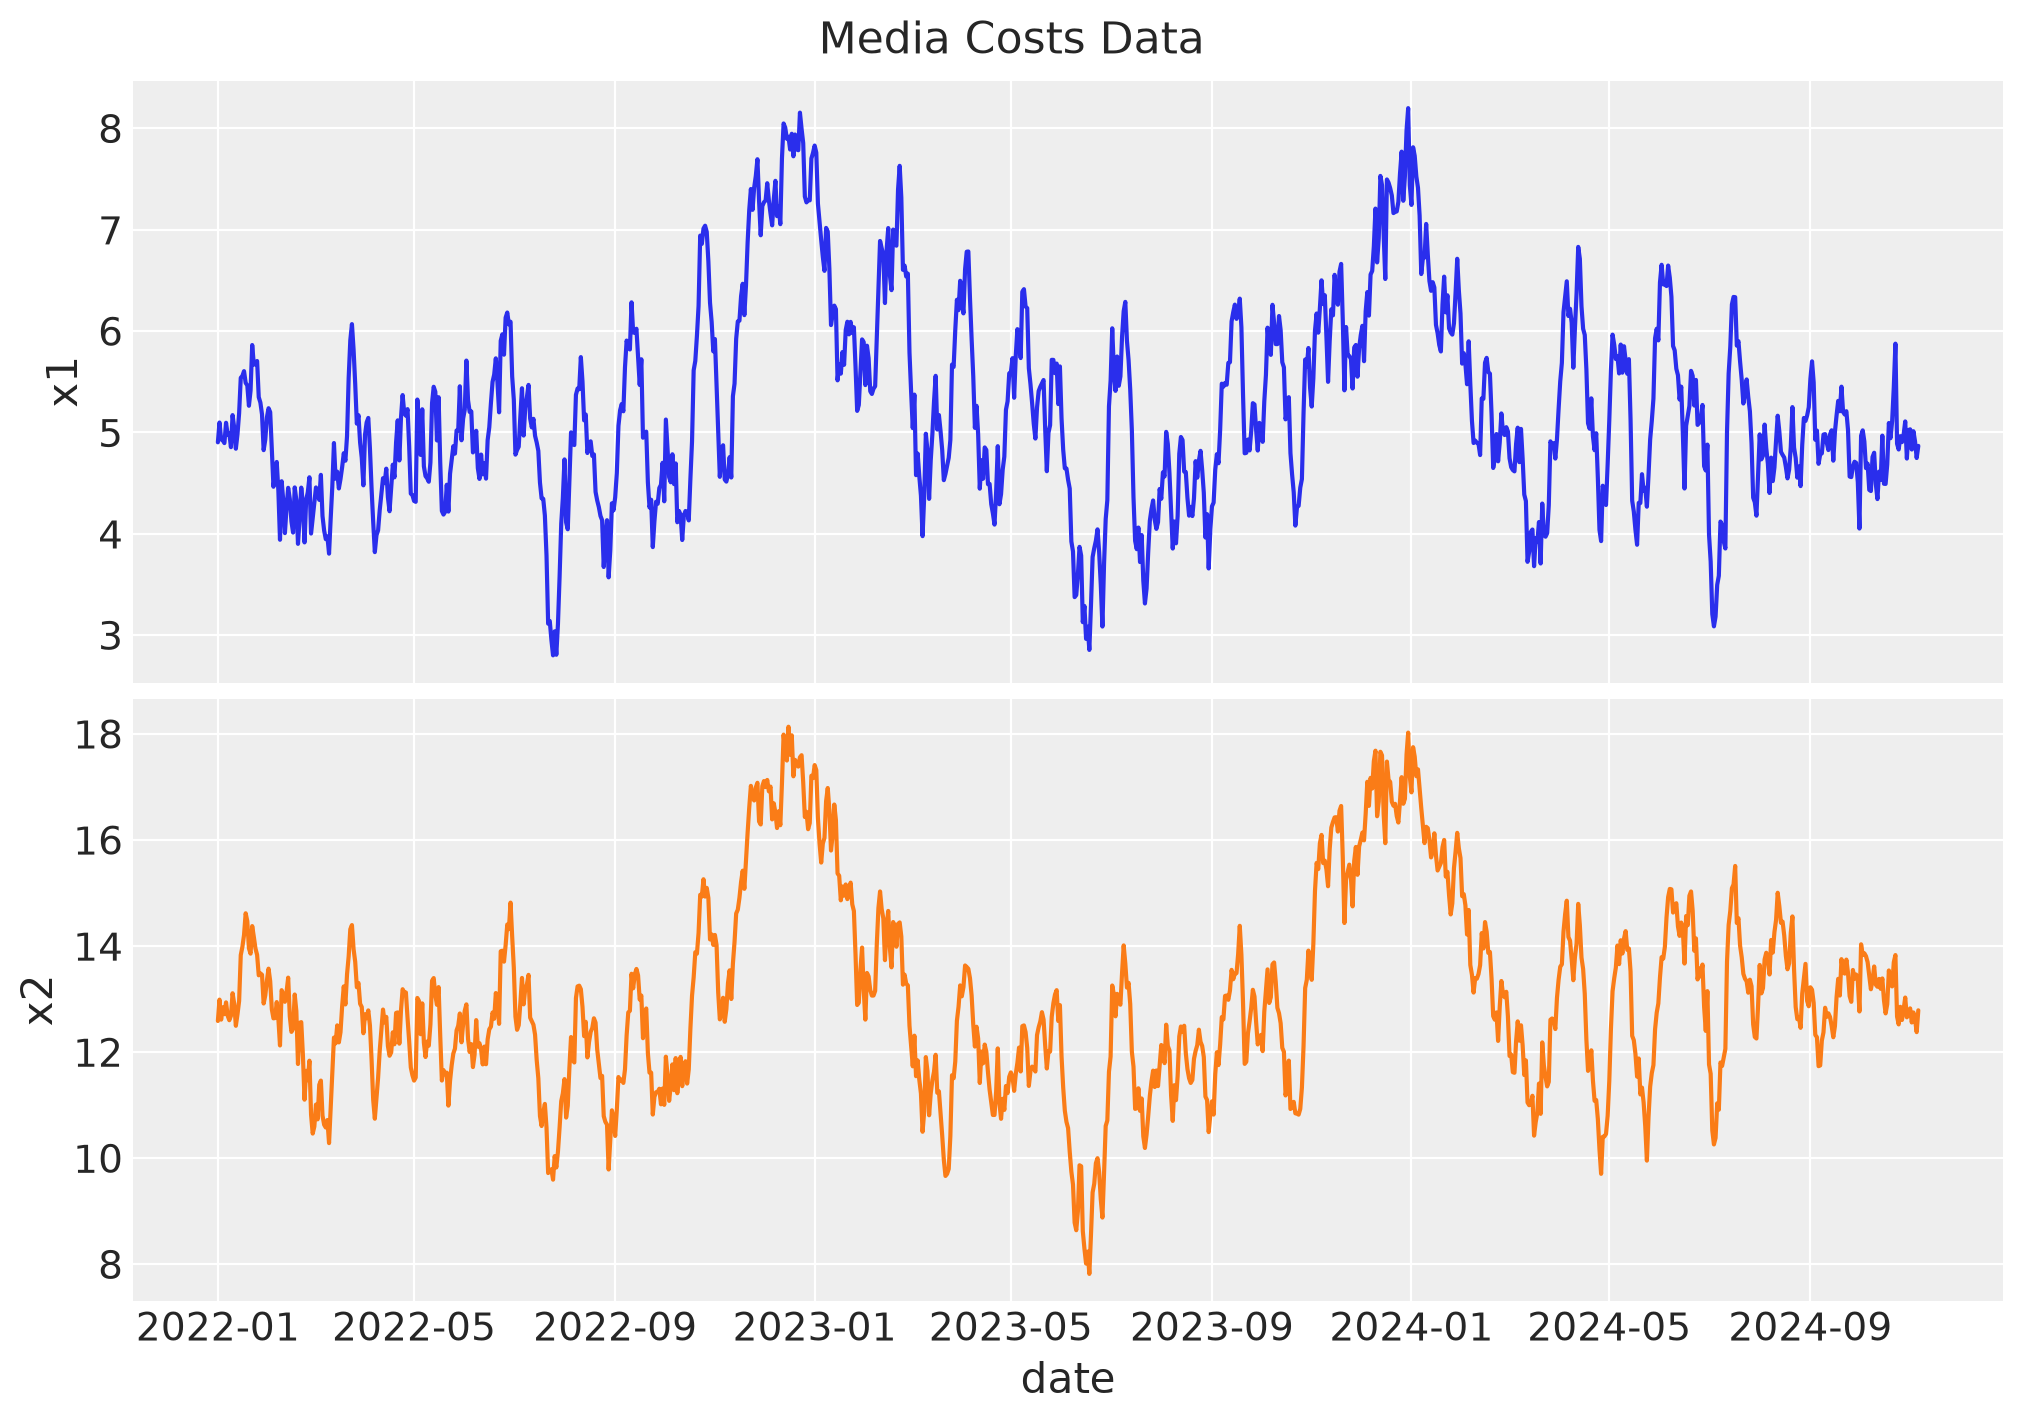

In [9]:
fig, ax = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 7), sharex=True, layout="constrained"
)
sns.lineplot(x="date_week", y="x1", data=df, color="C0", ax=ax[0])
sns.lineplot(x="date_week", y="x2", data=df, color="C1", ax=ax[1])
ax[1].set(xlabel="date")
fig.suptitle("Media Costs Data", fontsize=16);

The two generated signals wil represent the "impressions" of the two marketing channels. Basically, we are simulating the exposure that we would observe from a media platform, reported after we run a campaign.

The level of exposure doesn't impact our sales in a linear way, so we need to apply a transformation to account for that. We'll use a geometric adstock transformation, which is a common technique in marketing mix modeling to account for the adstock/lagging effect, and a michaelis-menten saturation to account for the diminishing returns effect.

Similar as the {ref}`mmm_example`. 

In [10]:
# apply geometric adstock transformation
alpha1: float = 0.6
alpha2: float = 0.2

df["x1_adstock"] = geometric_adstock(
    x=df["x1"].to_xarray(), alpha=alpha1, l_max=24, normalize=True, dim="index"
).eval()

df["x2_adstock"] = geometric_adstock(
    x=df["x2"].to_xarray(), alpha=alpha2, l_max=24, normalize=True, dim="index"
).eval()

# apply saturation transformation
lam1: float = 5.0
lam2: float = 9.0

alpha_mm1: float = 6
alpha_mm2: float = 12

df["x1_adstock_saturated"] = michaelis_menten(
    x=df["x1_adstock"].to_xarray(), lam=lam1, alpha=alpha_mm1
).eval()

df["x2_adstock_saturated"] = michaelis_menten(
    x=df["x2_adstock"].to_xarray(), lam=lam2, alpha=alpha_mm2
).eval()

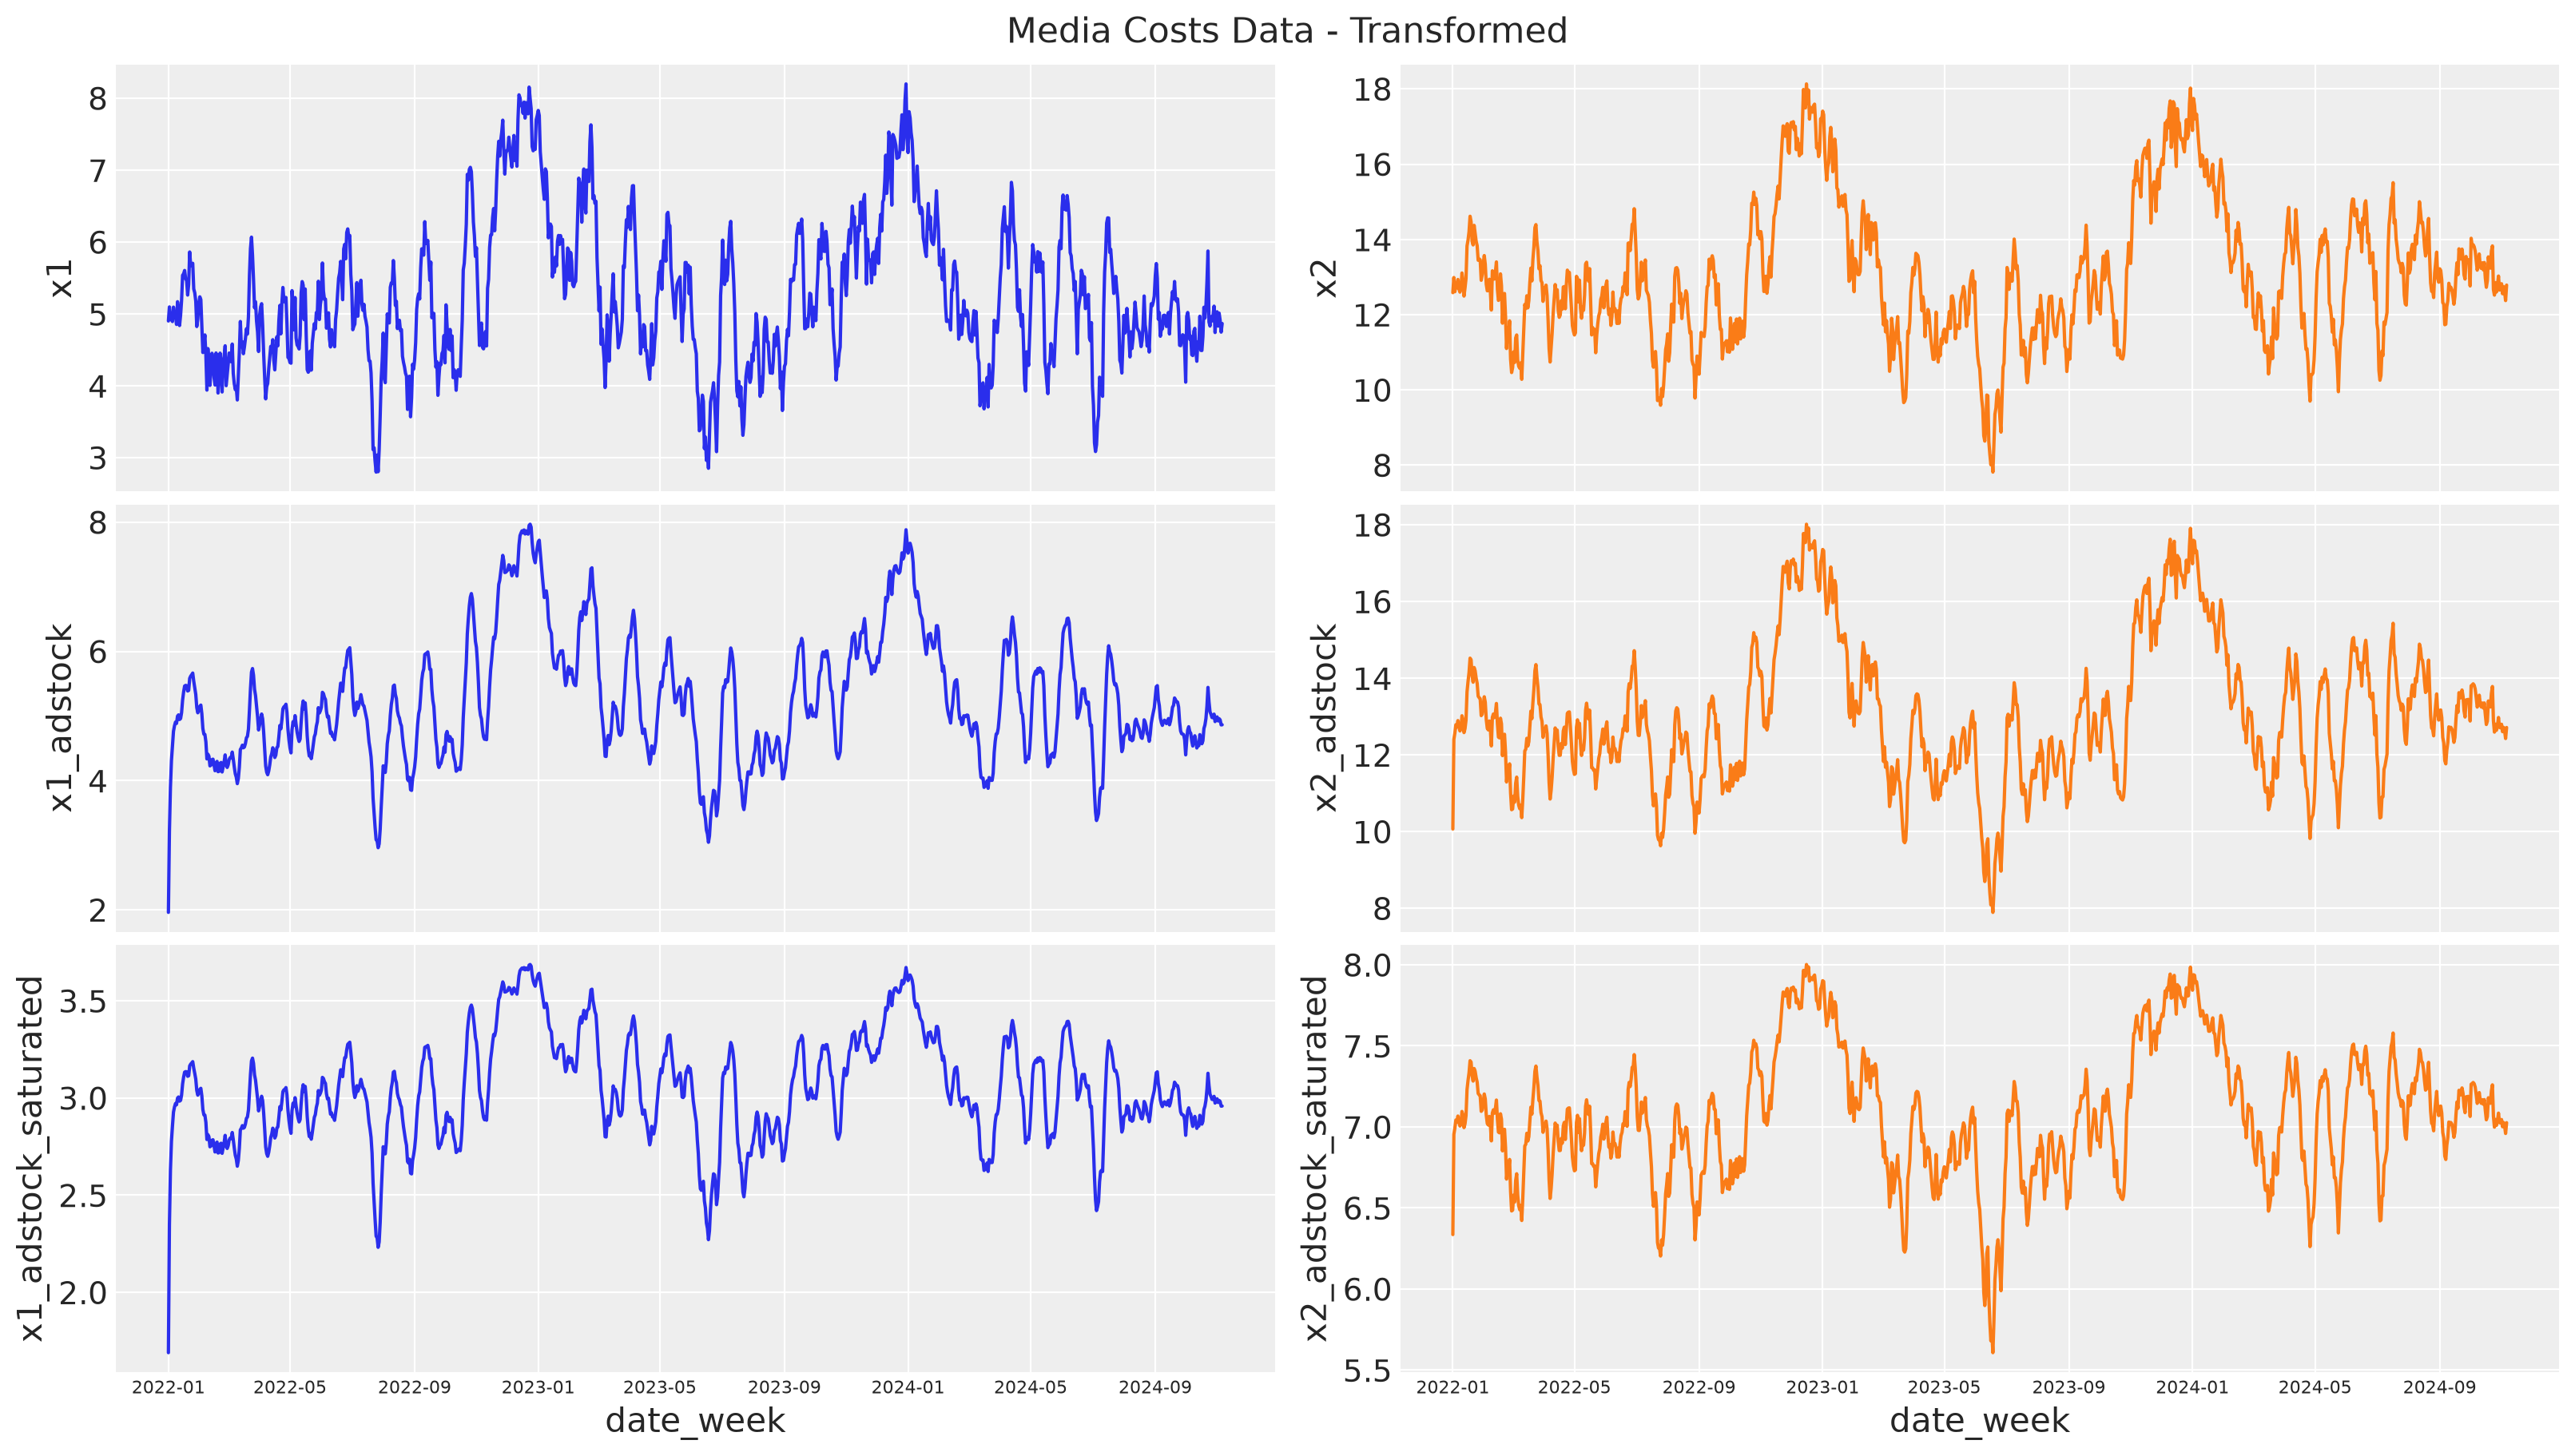

In [11]:
fig, ax = plt.subplots(
    nrows=3, ncols=2, figsize=(16, 9), sharex=True, sharey=False, layout="constrained"
)
sns.lineplot(x="date_week", y="x1", data=df, color="C0", ax=ax[0, 0])
sns.lineplot(x="date_week", y="x2", data=df, color="C1", ax=ax[0, 1])
sns.lineplot(x="date_week", y="x1_adstock", data=df, color="C0", ax=ax[1, 0])
sns.lineplot(x="date_week", y="x2_adstock", data=df, color="C1", ax=ax[1, 1])
sns.lineplot(x="date_week", y="x1_adstock_saturated", data=df, color="C0", ax=ax[2, 0])
sns.lineplot(x="date_week", y="x2_adstock_saturated", data=df, color="C1", ax=ax[2, 1])
fig.suptitle("Media Costs Data - Transformed", fontsize=16)
# adjust size of X axis
ax[2, 0].tick_params(axis="x", labelsize=8)
ax[2, 1].tick_params(axis="x", labelsize=8);

### Defining the Sales (Target)

Finally, we define the sales or revenue (target) variable, which is affected by the market growth, the competitor offers, the holiday contributions, the saturated media costs and a noise term.

The variable, $y$, is defined as follows:

$$
y_{t} = Intercept + f(MG_{t}) - f(C_{t}) + f(H_{t}) + m(I_{x1_t}) + m(I_{x2_t}) + \epsilon
$$

Where:
- **Intercept**: A baseline level of sales, set to 1.5, representing the base sales level in the absence of other effects.
- **Market Growth**: Represents the underlying trend in sales due to long-term growth, with an implicit coefficient of 1, adding a steady upward influence.
- **Competitor Offers**: Directly reduces sales, with an implicit coefficient of -1, simulating the negative impact of competitor actions on the target variable.
- **Holiday Contributions**: Adds sales spikes around holiday periods, capturing the seasonal increase in consumer demand.
- **$m(Impressions_{x1_t})$ and $m(Impressions_{x2_t})$**: Represent the **saturated adstock** values for the marketing channels $x1$ and $x2$.
- **Noise $\epsilon$**: A small random error term, drawn from a normal distribution with mean 0 and standard deviation 0.08, to account for unexplained variability in sales.

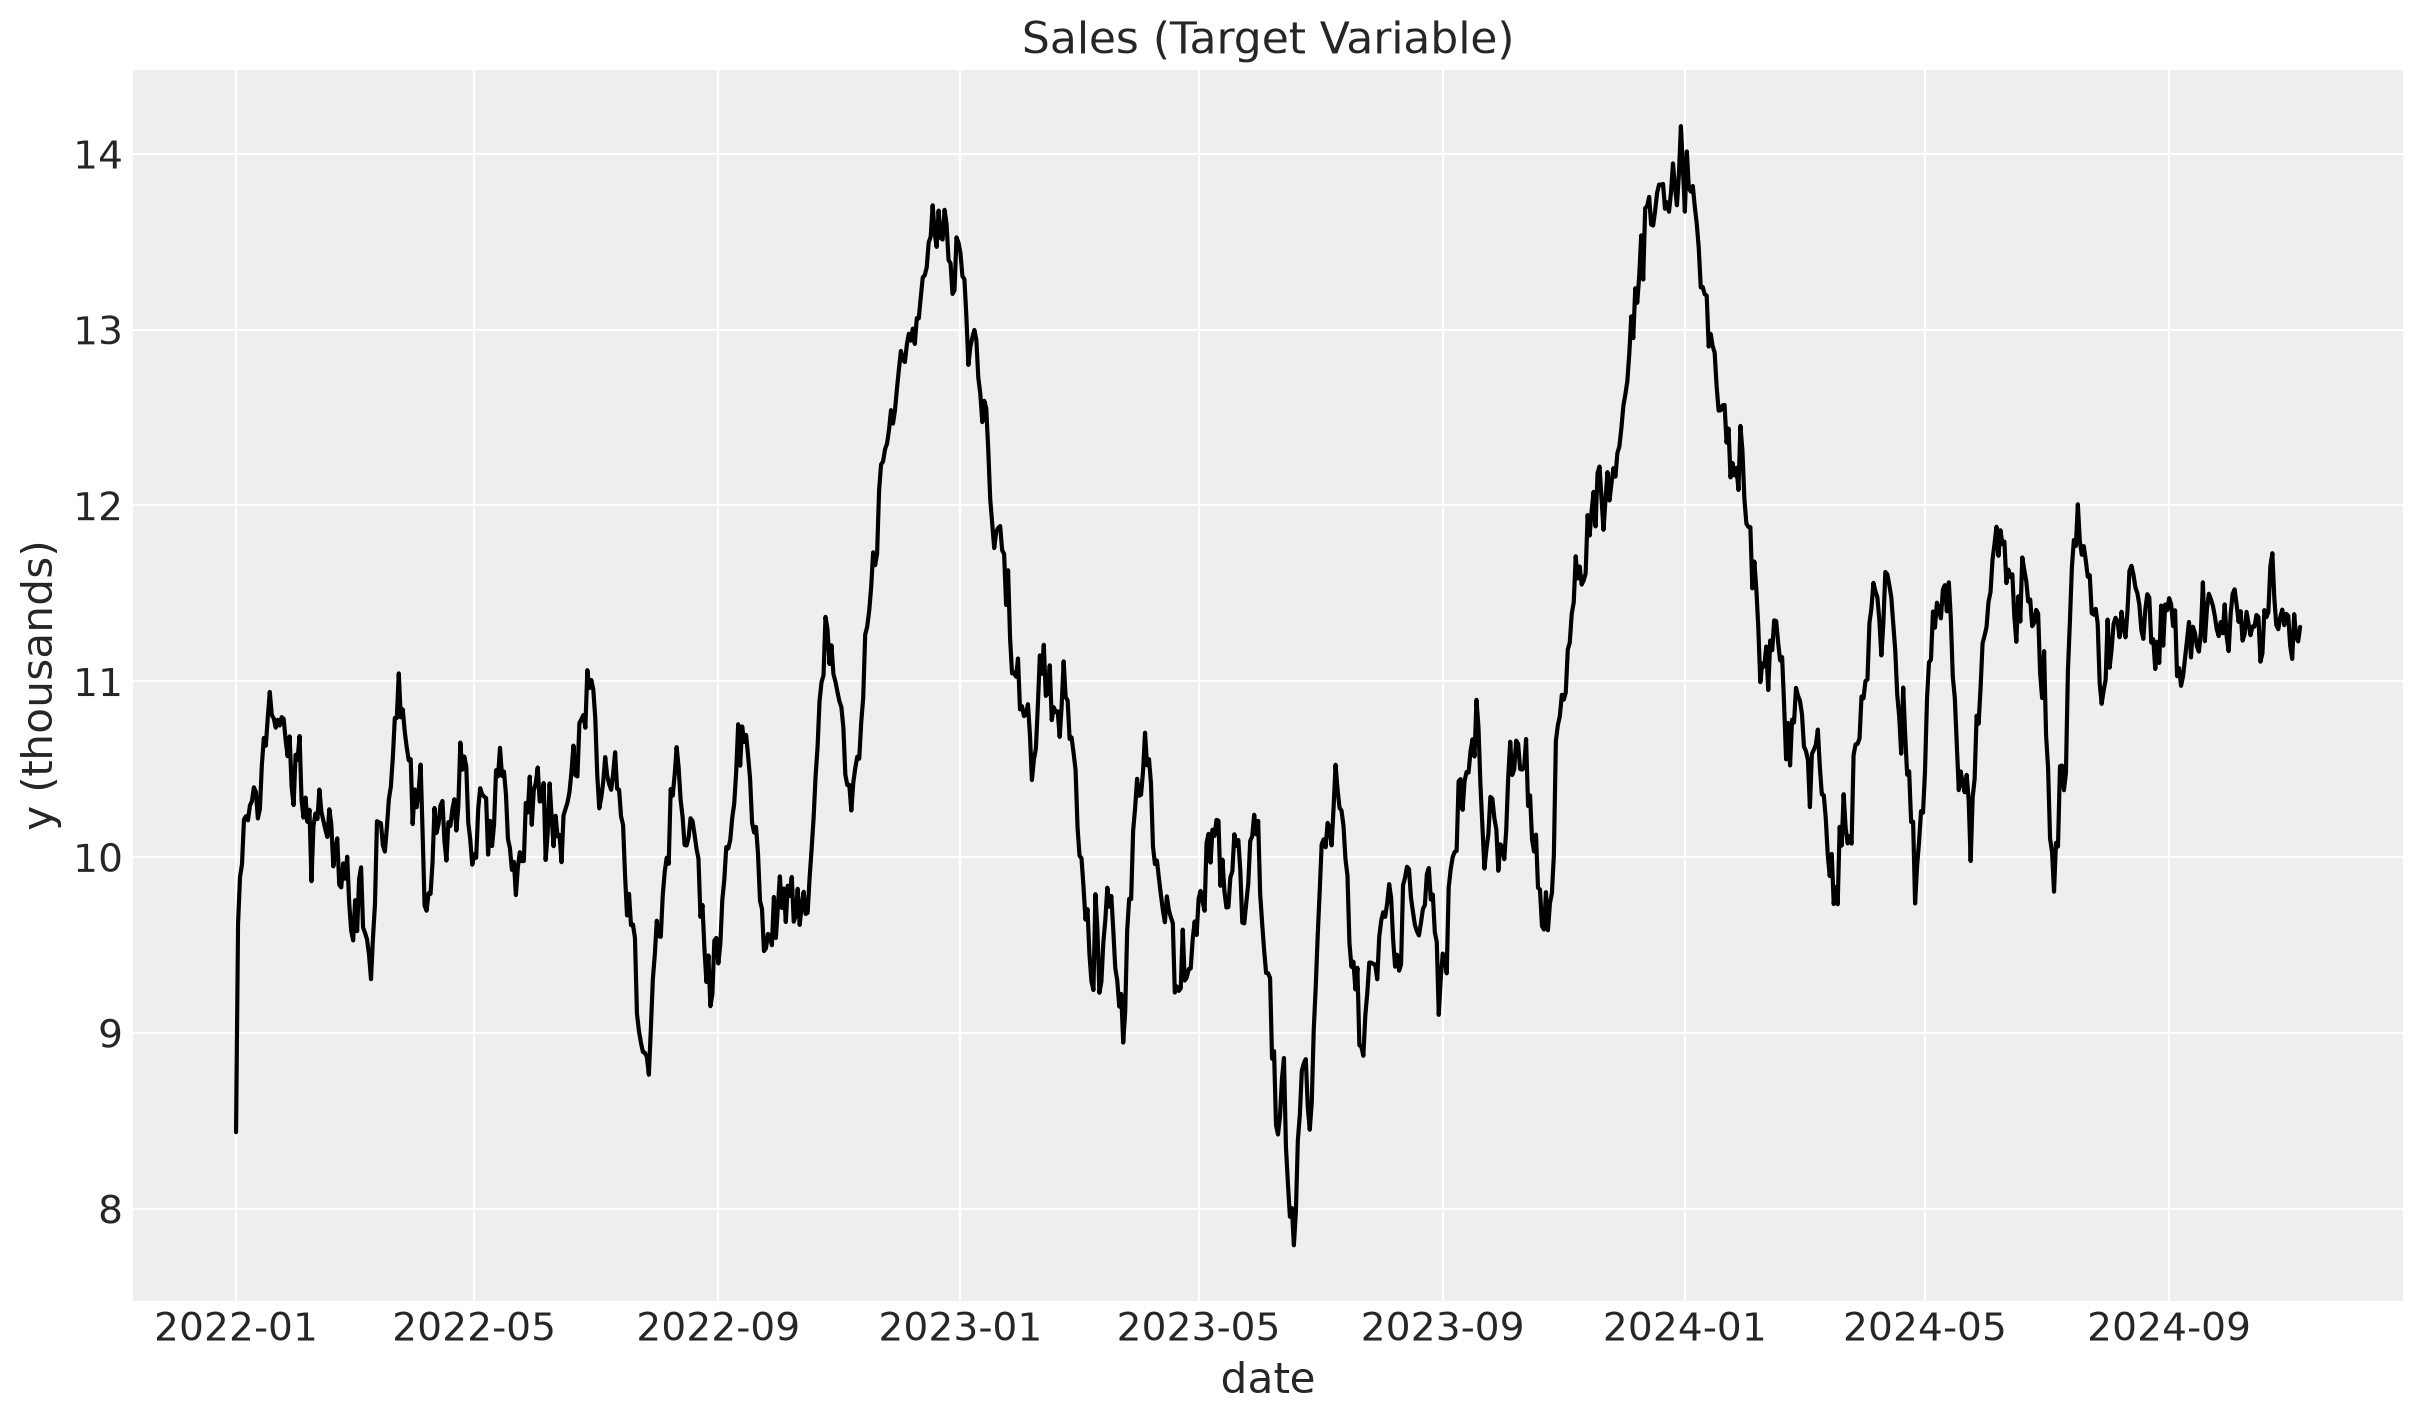

In [12]:
df["intercept"] = 1.5
df["epsilon"] = rng.normal(loc=0.0, scale=0.08, size=n)

df["y"] = (
    df["intercept"]
    + df["market_growth"]  # implicit coef 1
    - df["competitor_offers"]  # explicit coef -1
    + df["holiday_contributions"]
    + df["x1_adstock_saturated"]
    + df["x2_adstock_saturated"]
    + df["epsilon"]  # Noise
)

fig, ax = plt.subplots()
sns.lineplot(x="date_week", y="y", color="black", data=df, ax=ax)
ax.set(title="Sales (Target Variable)", xlabel="date", ylabel="y (thousands)");

In [13]:
columns_to_keep = [
    "date_week",
    "y",
    "x1",
    "x2",
]

data = df[columns_to_keep].copy()

Let’s recap what we’ve done so far:

- We created a hypothesis about how things in the world interact and how those interactions are connected.
- We turned our hypothesis into a mathematical model that reflects these connections.
- We generated data that fits with our hypothesis.
- Now we are ready to find the model that best explains our data.

In Bayesian terms, we call this the data generating process, which corresponds to the structural causal model in causal terms.

All models we write in PyMC are structural causal models. Even if we don’t aim for a causal interpretation, our model still seeks to explain a specific data generating process.

Recognizing this is crucial because it shapes our decisions when building the model and choosing which variables to include. After our previous work, we should have a good idea of which variables are most important in explaining sales. However, if we forget what we discussed earlier, we won't know how to start building the model.

## The Real Challenge

In real life, we don't know the actual data generating process; we only have observed data. Often, we receive a dataset like the one shown below.

In [14]:
data.head()

,date_week,y,x1,x2
0,2022-01-01,8.435918,4.901673,12.584369
1,2022-01-02,9.619534,5.097116,12.987150
2,2022-01-03,9.885896,4.930238,12.610042
3,2022-01-04,9.959450,4.921401,12.842278
4,2022-01-05,10.214027,4.894086,12.712858


If we have PyMC installed, the simplest approach would be to include all our variables in a model and run it. This is like using any model available on the market, checking correlations, and selecting the most relevant variables. This method essentially means, “Let’s control for everything that might relate to sales.”

> Note: This approach is not bad, but it misses using valuable information and prior knowledge about the business and its inner relationships.

We can separate the target variable from the potential factors that influence it. Then, we can begin training our initial correlation-based model.

In [15]:
X = data.drop("y", axis=1)
y = data["y"]

In [16]:
# sampling options for PyMC
sample_kwargs = {
    "tune": 500,
    "draws": 500,
    "chains": 10,
    "cores": 10,
    "nuts_sampler": "nutpie",
}

In [17]:
correlational_mmm = MMM(
    sampler_config=sample_kwargs,
    target_column="y",
    date_column="date_week",
    adstock=GeometricAdstock(l_max=24),
    saturation=MichaelisMentenSaturation(),
    channel_columns=["x1", "x2"],
)
correlational_mmm.build_model(X=X, y=y)
correlational_mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "intercept_contribution",
        "y",
    ]
)

With the small lines of code above, our media mix model is set up, and we can now start training it.

In [18]:
# sampling options for PyMC
correlational_mmm.fit(X=X, y=y, target_accept=0.90, random_seed=rng)
correlational_mmm.sample_posterior_predictive(
    X, extend_idata=True, combined=True, random_seed=rng
)

NUTS[nutpie]: [y_sigma, adstock_alpha, saturation_lam, saturation_alpha, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

<xarray.Dataset> Size: 83MB
Dimensions:           (date: 1041, sample: 5000)
Coordinates:
  * date              (date) datetime64[us] 8kB 2022-01-01 ... 2024-11-06
  * sample            (sample) object 40kB MultiIndex
  * chain             (sample) int64 40kB 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9
  * draw              (sample) int64 40kB 0 1 2 3 4 5 ... 495 496 497 498 499
Data variables:
    y                 (date, sample) float64 42MB 0.563 0.5496 ... 0.782 0.7287
    y_original_scale  (date, sample) float64 42MB 7.971 7.781 ... 11.07 10.32
Attributes:
    created_at:                 2026-09-19T04:49:03.186047+00:00
    creation_library:           ArviZ
    creation_library_version:   1.2.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  6.2.0
    sample_dims:                ['sample']

Since PyMC is structural, we can show our model as a directed acyclic graph (DAG). This graph helps us see how the parameters and variables relate to each other and understand our decisions in the modeling process.

We can use the `model_to_graphviz` function to create this visual representation.

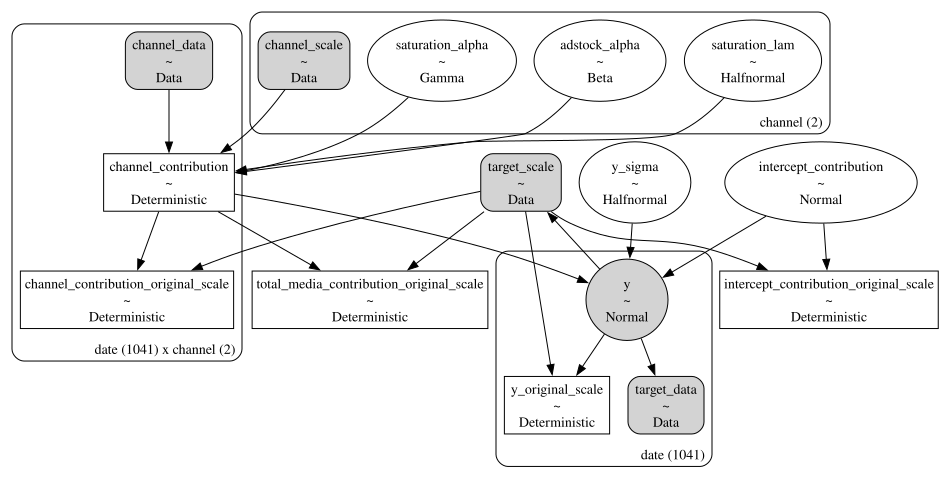

In [19]:
pm.model_to_graphviz(model=correlational_mmm.model)

Our DAG is quite simple. It includes our channels, which have two dimensions: date and channel. It also has an intercept variable that captures baseline sales or revenue, which are factors outside of our control, and a term to reflect random variance.

In simpler terms, we can express the underlying function of this media mix model as:

$$
\begin{aligned}
\mu & = \beta_0 \cdot \text{baseline} +
 m(\text{x1}, \theta_{\text{x1}}) +
 m(\text{x2}, \theta_{\text{x2}})
\end{aligned}
$$

Here:
- $\mu$ represents the predicted outcome variable (like sales or revenue) based on the combined effects of our input variables.
- $\beta_0$ is the coefficient for the baseline variable.
- $m(\text{x1}, \theta_{\text{x1}})$ and $m(\text{x2}, \theta_{\text{x2}})$ are non-linear transformations of $x1$ and $x2$ that capture their varying impacts.

Based on this, we think this function will help us understand the impact of $x1$ and $x2$. Thus, we can outline the causal DAG we believe is correct.

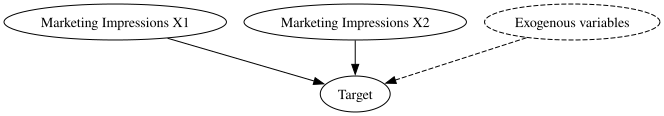

In [20]:
# Initialize a directed graph
naive_causal_mmm_graph = Digraph()

# Add nodes
naive_causal_mmm_graph.node("X1", "Marketing Impressions X1")
naive_causal_mmm_graph.node("X2", "Marketing Impressions X2")
naive_causal_mmm_graph.node("E", "Exogenous variables", style="dashed")
naive_causal_mmm_graph.node("T", "Target")

naive_causal_mmm_graph.edge("E", "T", style="dashed")
naive_causal_mmm_graph.edge("X1", "T")
naive_causal_mmm_graph.edge("X2", "T")

# Render the graph to SVG and display it inline
svg_str = naive_causal_mmm_graph.pipe(format="svg")
display(SVG(svg_str))

How can we infer this DAG from our current model?

During the development of our model, we established a specific structure and flow for our data. We concluded that the impacts of our channels operate independently of each other. Moreover, we determined that if any component of our ecosystem is missing, its influence will be accounted for by the baseline term due to this equation. As you can see, even by adopting this basic model, we are making significant assumptions.

On one hand, you are assuming that the impact is not linear by applying these transformations, and you are suggesting that the impact is positive and that there may be a maximum delay of a certain number of days.

You've even defined the direction of your relationships. By defining these relationships and assuming no direct causal connections between our variables, we can conclude that, if the nature of their relationship is accurately represented by the provided equation, then by controlling the relevant channels, we could uncover their true effects. 

This leads us to which causal DAG we assume is correct, based on our previous assumptions. If you recognize this process, congratulations! You've created a generative model or Structural Causal Model, with a Structural Causal Equation, using PyMC-marketing.

> Note: As you can see, based on our assumptions and the variables we included, we can backtrack and infer the causal DAG we are inherently assuming. This backtracking process can be using and formalize on causal discovery algorithms to automatically infer the several causal DAGs based on how our regression model and their estimates respond to the data.

However, this Causal DAG does not depict the true Causal DAG. Since our PyMC model is structural and causal, we must ask: *What happens if I create a model with a different causal structure than the real one?*

In [21]:
# Number of diverging samples
correlational_mmm.idata["sample_stats"]["diverging"].sum().item()

Because all PyMC models are generative models, they are able to "talk" about the causal relationships that are present in the data generating process. If we have a model that is not consistent with the true causal relationships, the model will fail during the exploration of the parameter space.

For example, if you assume that variable  A  causes variable  B  (i.e.,  A -> B ), but in reality,  B  causes  A  or they are confounded by an unobserved variable, your model’s structure misrepresents the actual relationships. This misalignment creates inconsistencies between the model and the data, resulting in a posterior distribution that is challenging for the sampler to explore. The posterior may exhibit pathological features such as multimodality, strong correlations between parameters, or regions of high curvature.

A model like this will get divergencies, because these occur when the numerical integrator used in Hamiltonian Monte Carlo (HMC) cannot accurately simulate the trajectory through the parameter space, often due to steep gradients or discontinuities in the posterior. If you think about it, incorrect causal assumptions may force the sampler into incompatible regions of the parameter space, causing the numerical integration to fail.

When we evaluate time series generative models, particulary bayesian models, we should always evaluate models with additional metrics on top of the pure fit metrics, such as divergences, rhat, ess, etc.


Lets observe the fit of our current model 👀

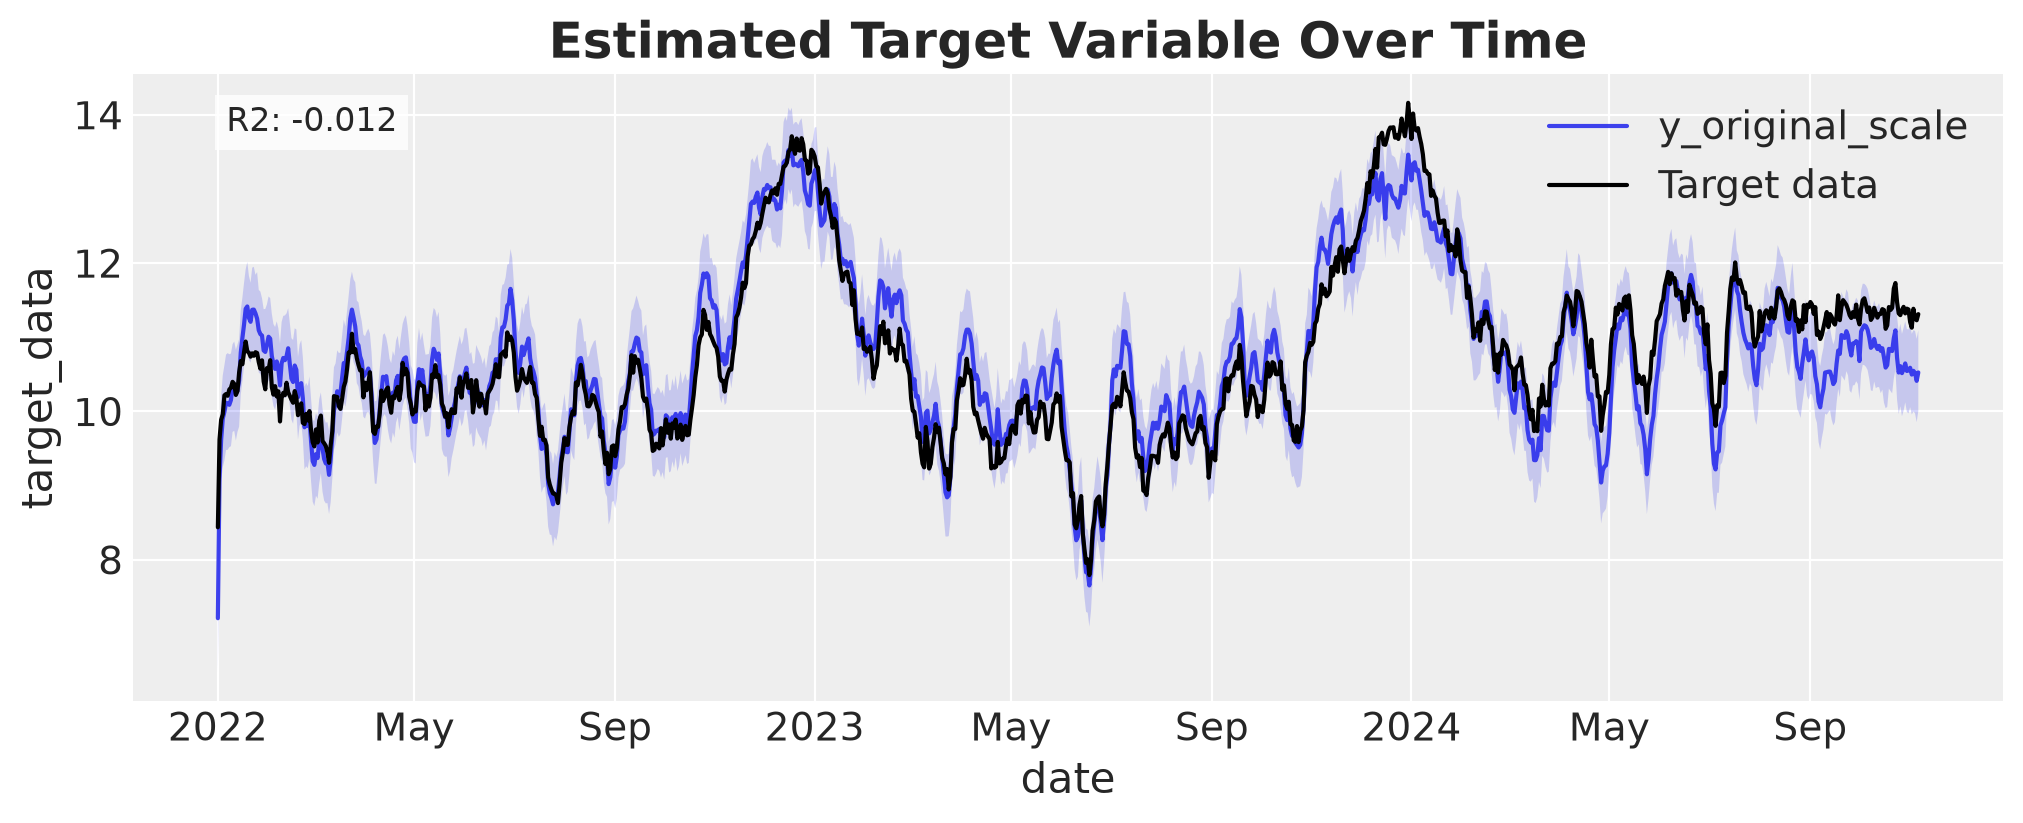

In [22]:
r2 = bayesian_r2(correlational_mmm.idata, pred_mean="y_original_scale")[0]
fig, ax = correlational_mmm.plot.posterior_predictive(var=["y_original_scale"])
ax = ax.flatten()
correlational_mmm.idata.constant_data.target_data.plot(
    label="Target data",
    color="black",
    ax=ax[0],
)
ax[0].text(
    0.05,
    0.95,
    f"R2: {r2:.3f}",
    transform=ax[0].transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
)
ax[0].legend()
ax[0].set_title("Estimated Target Variable Over Time", fontsize=18, fontweight="bold");

Great, our model looks amazing! At first glance, our model evaluation appears quite satisfactory. The $R^2$ value is decent, and the uncertainty in the credible intervals is manageable.

However, the pressing question remains: are we truly capturing the underlying causal signals?

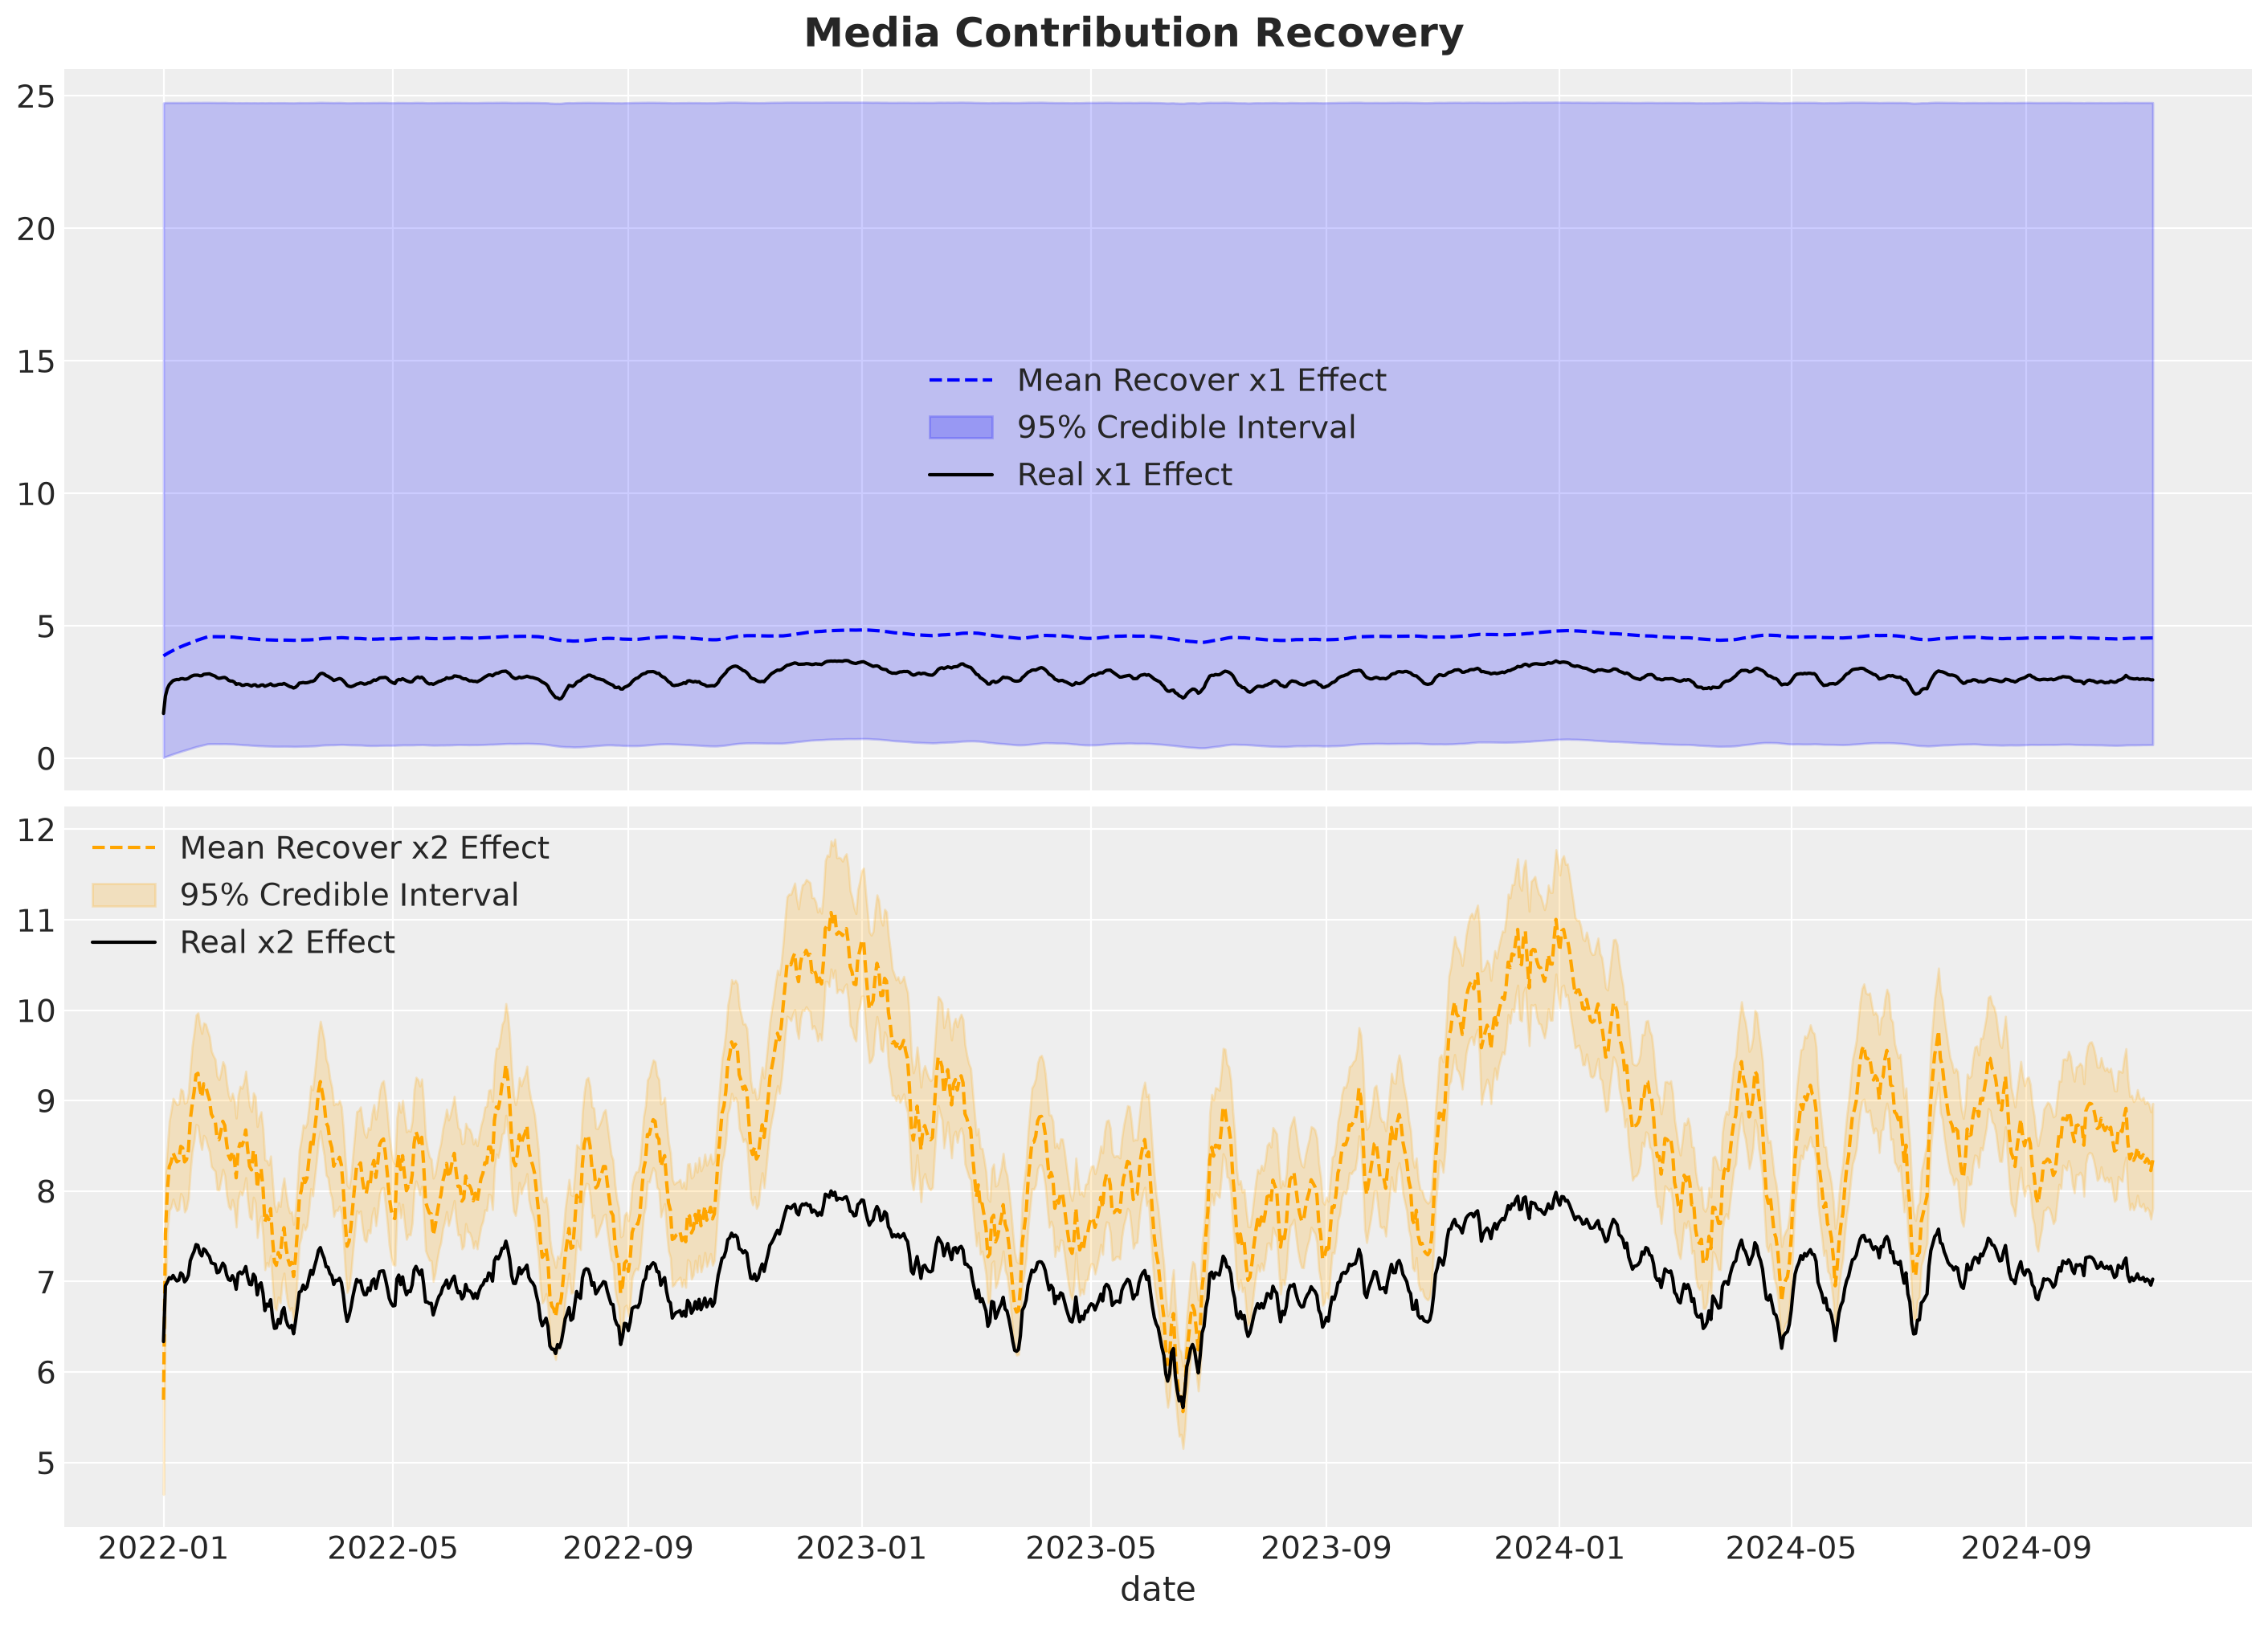

In [23]:
initial_model_recover_effect = az.hdi(
    correlational_mmm.fit_result["channel_contribution_original_scale"], prob=0.95
)
initial_model_mean_effect = correlational_mmm.fit_result[
    "channel_contribution_original_scale"
].mean(dim=["chain", "draw"])
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
# Social media
ax[0].plot(
    date_range,
    initial_model_mean_effect.sel(channel="x1"),
    label="Mean Recover x1 Effect",
    linestyle="--",
    color="blue",
)
ax[0].fill_between(
    date_range,
    initial_model_recover_effect.sel(ci_bound="lower").sel(channel="x1"),
    initial_model_recover_effect.sel(ci_bound="upper").sel(channel="x1"),
    alpha=0.2,
    label="95% Credible Interval",
    color="blue",
)
ax[0].plot(
    date_range, df["x1_adstock_saturated"], label="Real x1 Effect", color="black"
)
# google
ax[1].plot(
    date_range,
    initial_model_mean_effect.sel(channel="x2"),
    label="Mean Recover x2 Effect",
    linestyle="--",
    color="orange",
)
ax[1].fill_between(
    date_range,
    initial_model_recover_effect.sel(ci_bound="lower").sel(channel="x2"),
    initial_model_recover_effect.sel(ci_bound="upper").sel(channel="x2"),
    alpha=0.2,
    label="95% Credible Interval",
    color="orange",
)
ax[1].plot(
    date_range, df["x2_adstock_saturated"], label="Real x2 Effect", color="black"
)
# formatting
ax[0].legend()
ax[1].legend()
plt.grid(True)
ax[1].set(xlabel="date")
fig.suptitle("Media Contribution Recovery", fontsize=18, fontweight="bold");

Our model struggles to accurately capture the true causal effect of media variables, suggesting it may be misspecified.

In this context, although we can use the true model to compare the actual effects with the model's recovered effects, real-life situations often lack this clarity. Therefore, we need methods to identify and compare the recovered effects with the true ones.

This is where **CausalPy** is useful. It enables the creation of quasi-experiments to determine the causal impact of media variables, allowing for comparison between our model's results and those from these experiments. You can learn more about [CausalPy here](https://causalpy.readthedocs.io/en/stable/).

## Utilizing Causal Identification
Instead of randomly adding variables to our regression, we should use a causal framework to build our model. A language which help us to translate our ideas and hypothesis into a graphical representation which we can interrogate. Doing so, we can understant if we are overlooking an important variable.

In [24]:
naive_causal_dag_str = """
digraph {
    x1 -> y;
    x2 -> y;
    holiday_signal -> y;
}
"""

In [25]:
naive_causal_mmm = MMM(
    sampler_config=sample_kwargs,
    target_column="y",
    date_column="date_week",
    adstock=GeometricAdstock(l_max=24),
    saturation=MichaelisMentenSaturation(),
    channel_columns=["x1", "x2"],
    control_columns=["holiday_signal"],
    # new columns
    outcome_node="y",
    dag=naive_causal_dag_str,
)

naive_causal_mmm.build_model(X=X, y=y)
naive_causal_mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "intercept_contribution",
        "y",
    ]
)

We’ve added a new column called `outcome_node` for our target variable and defined the `dag` parameter as a representation of the causal Directed Acyclic Graph (DAG). We included `holiday_signal` as a control variable in our model because it significantly influences the target variable and may have been missed before. After ran that, we received a warning that channel columns are being treated as default treatment variables, indicating they are our focus for estimating the true causal impact (default behavior).

Now, we can examine the adjustment set of variables needed to reveal the true causal effect of our treatment variables.

In [26]:
(
    naive_causal_mmm.causal_graphical_model.adjustment_set,
    naive_causal_mmm.causal_graphical_model.minimal_adjustment_set,
    naive_causal_mmm.causal_graphical_model.is_backdoor_identified,
)

([], [], True)

Great, we got a new piece of important information. We are missing the `holiday_signal` variable in the adjustment set, meaning, to find the true causal effect of `x1` and `x2`, we don’t need to control for `holiday_signal`. So, why we could not recover the true causal effect of `x1` and `x2` before? Perhaps the specified DAG was not true, meaning its possible that the relationship between `x1` and `x2` is confounded by the `holiday_signal` variable?

Lets see if this is the case.

In [27]:
naive_causal_dag_str_v2 = """
digraph {
    x1 -> y;
    x2 -> y;
    holiday_signal -> y;
    holiday_signal -> x1;
    holiday_signal -> x2;
}
"""

naive_causal_mmm_v2 = MMM(
    sampler_config=sample_kwargs,
    target_column="y",
    date_column="date_week",
    adstock=GeometricAdstock(l_max=24),
    saturation=MichaelisMentenSaturation(),
    channel_columns=["x1", "x2"],
    control_columns=["holiday_signal"],
    # new columns
    outcome_node="y",
    dag=naive_causal_dag_str_v2,
)

naive_causal_mmm_v2.build_model(X=X, y=y)
naive_causal_mmm_v2.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "intercept_contribution",
        "y",
    ]
)

(
    naive_causal_mmm_v2.causal_graphical_model.adjustment_set,
    naive_causal_mmm_v2.causal_graphical_model.minimal_adjustment_set,
    naive_causal_mmm_v2.causal_graphical_model.is_backdoor_identified,
)

(['holiday_signal'], ['holiday_signal'], True)

Now, with a new adjustment set, we see that if we do not control for `holiday_signal`, we cannot identify the true causal effect of `x1` and `x2` since they are influenced by this variable. This looks more close to what happened before, after compare the true contribution of `x1` and `x2` with the recovered contribution.

> Note: We define this adjustment set using the `CausalGraphModel` class. We rely on `dowhy` to help us identify the adjustment set. You can learn more about `dowhy` [here](https://www.pywhy.org/dowhy/v0.9.1/). 

We use the `backdoor` criterion to choose the adjustment set. This means we look for variables that, when we control for them, block all the backdoor paths between `x1` and `x2`. These paths can create false links between the treatment and outcome variables. If we don’t address these paths, our causal estimates may be off. To understand the causal effect accurately, we need to block these paths by adjusting for the confounding variables. You can read more about the backdoor criterion in Aleksander Molak's book [here](https://www.amazon.com/Causal-Inference-Discovery-Python-learning/dp/1804612987).

Now, let’s say we create a new variable called `holiday_signal` to control for the holiday effect. Adding this variable to our dataset should help us find the true causal effect of `x1` and `x2`, right?

In [28]:
data["holiday_signal"] = holiday_signal
data.head()

,date_week,y,x1,x2,holiday_signal
0,2022-01-01,8.435918,4.901673,12.584369,5.244234e-45
1,2022-01-02,9.619534,5.097116,12.987150,9.276916e-45
2,2022-01-03,9.885896,4.930238,12.610042,1.638439e-44
3,2022-01-04,9.959450,4.921401,12.842278,2.889097e-44
4,2022-01-05,10.214027,4.894086,12.712858,5.086267e-44


In [29]:
X = data.drop("y", axis=1)
y = data["y"]

In [30]:
naive_causal_mmm_v2.fit(X=X, y=y, target_accept=0.90, random_seed=rng)
naive_causal_mmm_v2.sample_posterior_predictive(
    X, extend_idata=True, combined=True, random_seed=rng
)

NUTS[nutpie]: [y_sigma, gamma_control, adstock_alpha, saturation_lam, saturation_alpha, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

<xarray.Dataset> Size: 83MB
Dimensions:           (date: 1041, sample: 5000)
Coordinates:
  * date              (date) datetime64[us] 8kB 2022-01-01 ... 2024-11-06
  * sample            (sample) object 40kB MultiIndex
  * chain             (sample) int64 40kB 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9
  * draw              (sample) int64 40kB 0 1 2 3 4 5 ... 495 496 497 498 499
Data variables:
    y                 (date, sample) float64 42MB 0.5453 0.5246 ... 0.7401
    y_original_scale  (date, sample) float64 42MB 7.72 7.427 ... 10.13 10.48
Attributes:
    created_at:                 2026-09-19T04:49:44.070314+00:00
    creation_library:           ArviZ
    creation_library_version:   1.2.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  6.2.0
    sample_dims:                ['sample']

We got even more divergencies 🤪, whats happening here? Everything is worse? Even if we added a new variable to control for the `holiday_signal`? This looks weird, because we are adding a variable that should help us to identify the true causal effect of `x1` and `x2`.

Lets see the fit of our model 👀

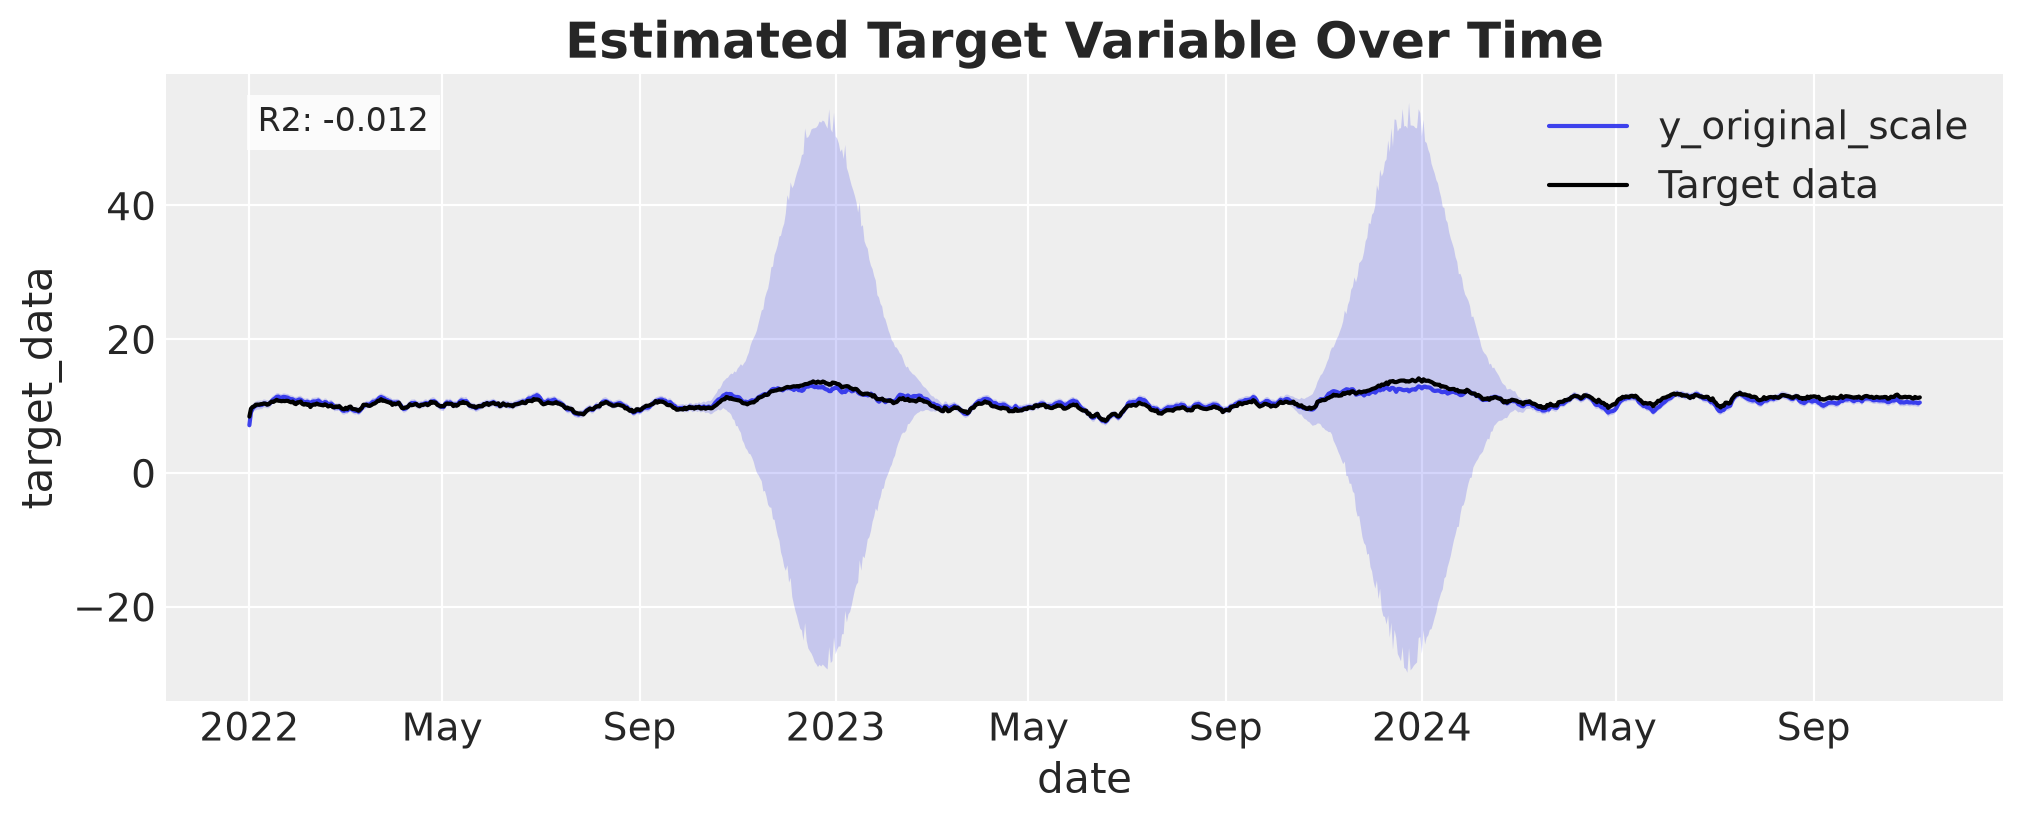

In [31]:
r2 = bayesian_r2(naive_causal_mmm_v2.idata, pred_mean="y_original_scale")[0]
fig, ax = naive_causal_mmm_v2.plot.posterior_predictive(var=["y_original_scale"])
ax = ax.flatten()
naive_causal_mmm_v2.idata.constant_data.target_data.plot(
    label="Target data",
    color="black",
    ax=ax[0],
)
ax[0].text(
    0.05,
    0.95,
    f"R2: {r2:.3f}",
    transform=ax[0].transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
)
ax[0].legend()
ax[0].set_title("Estimated Target Variable Over Time", fontsize=18, fontweight="bold");

Somehow $R^2$ is higher than before, could be this a good signal? Maybe are we recovering the true causal effect of `x1` and `x2`?

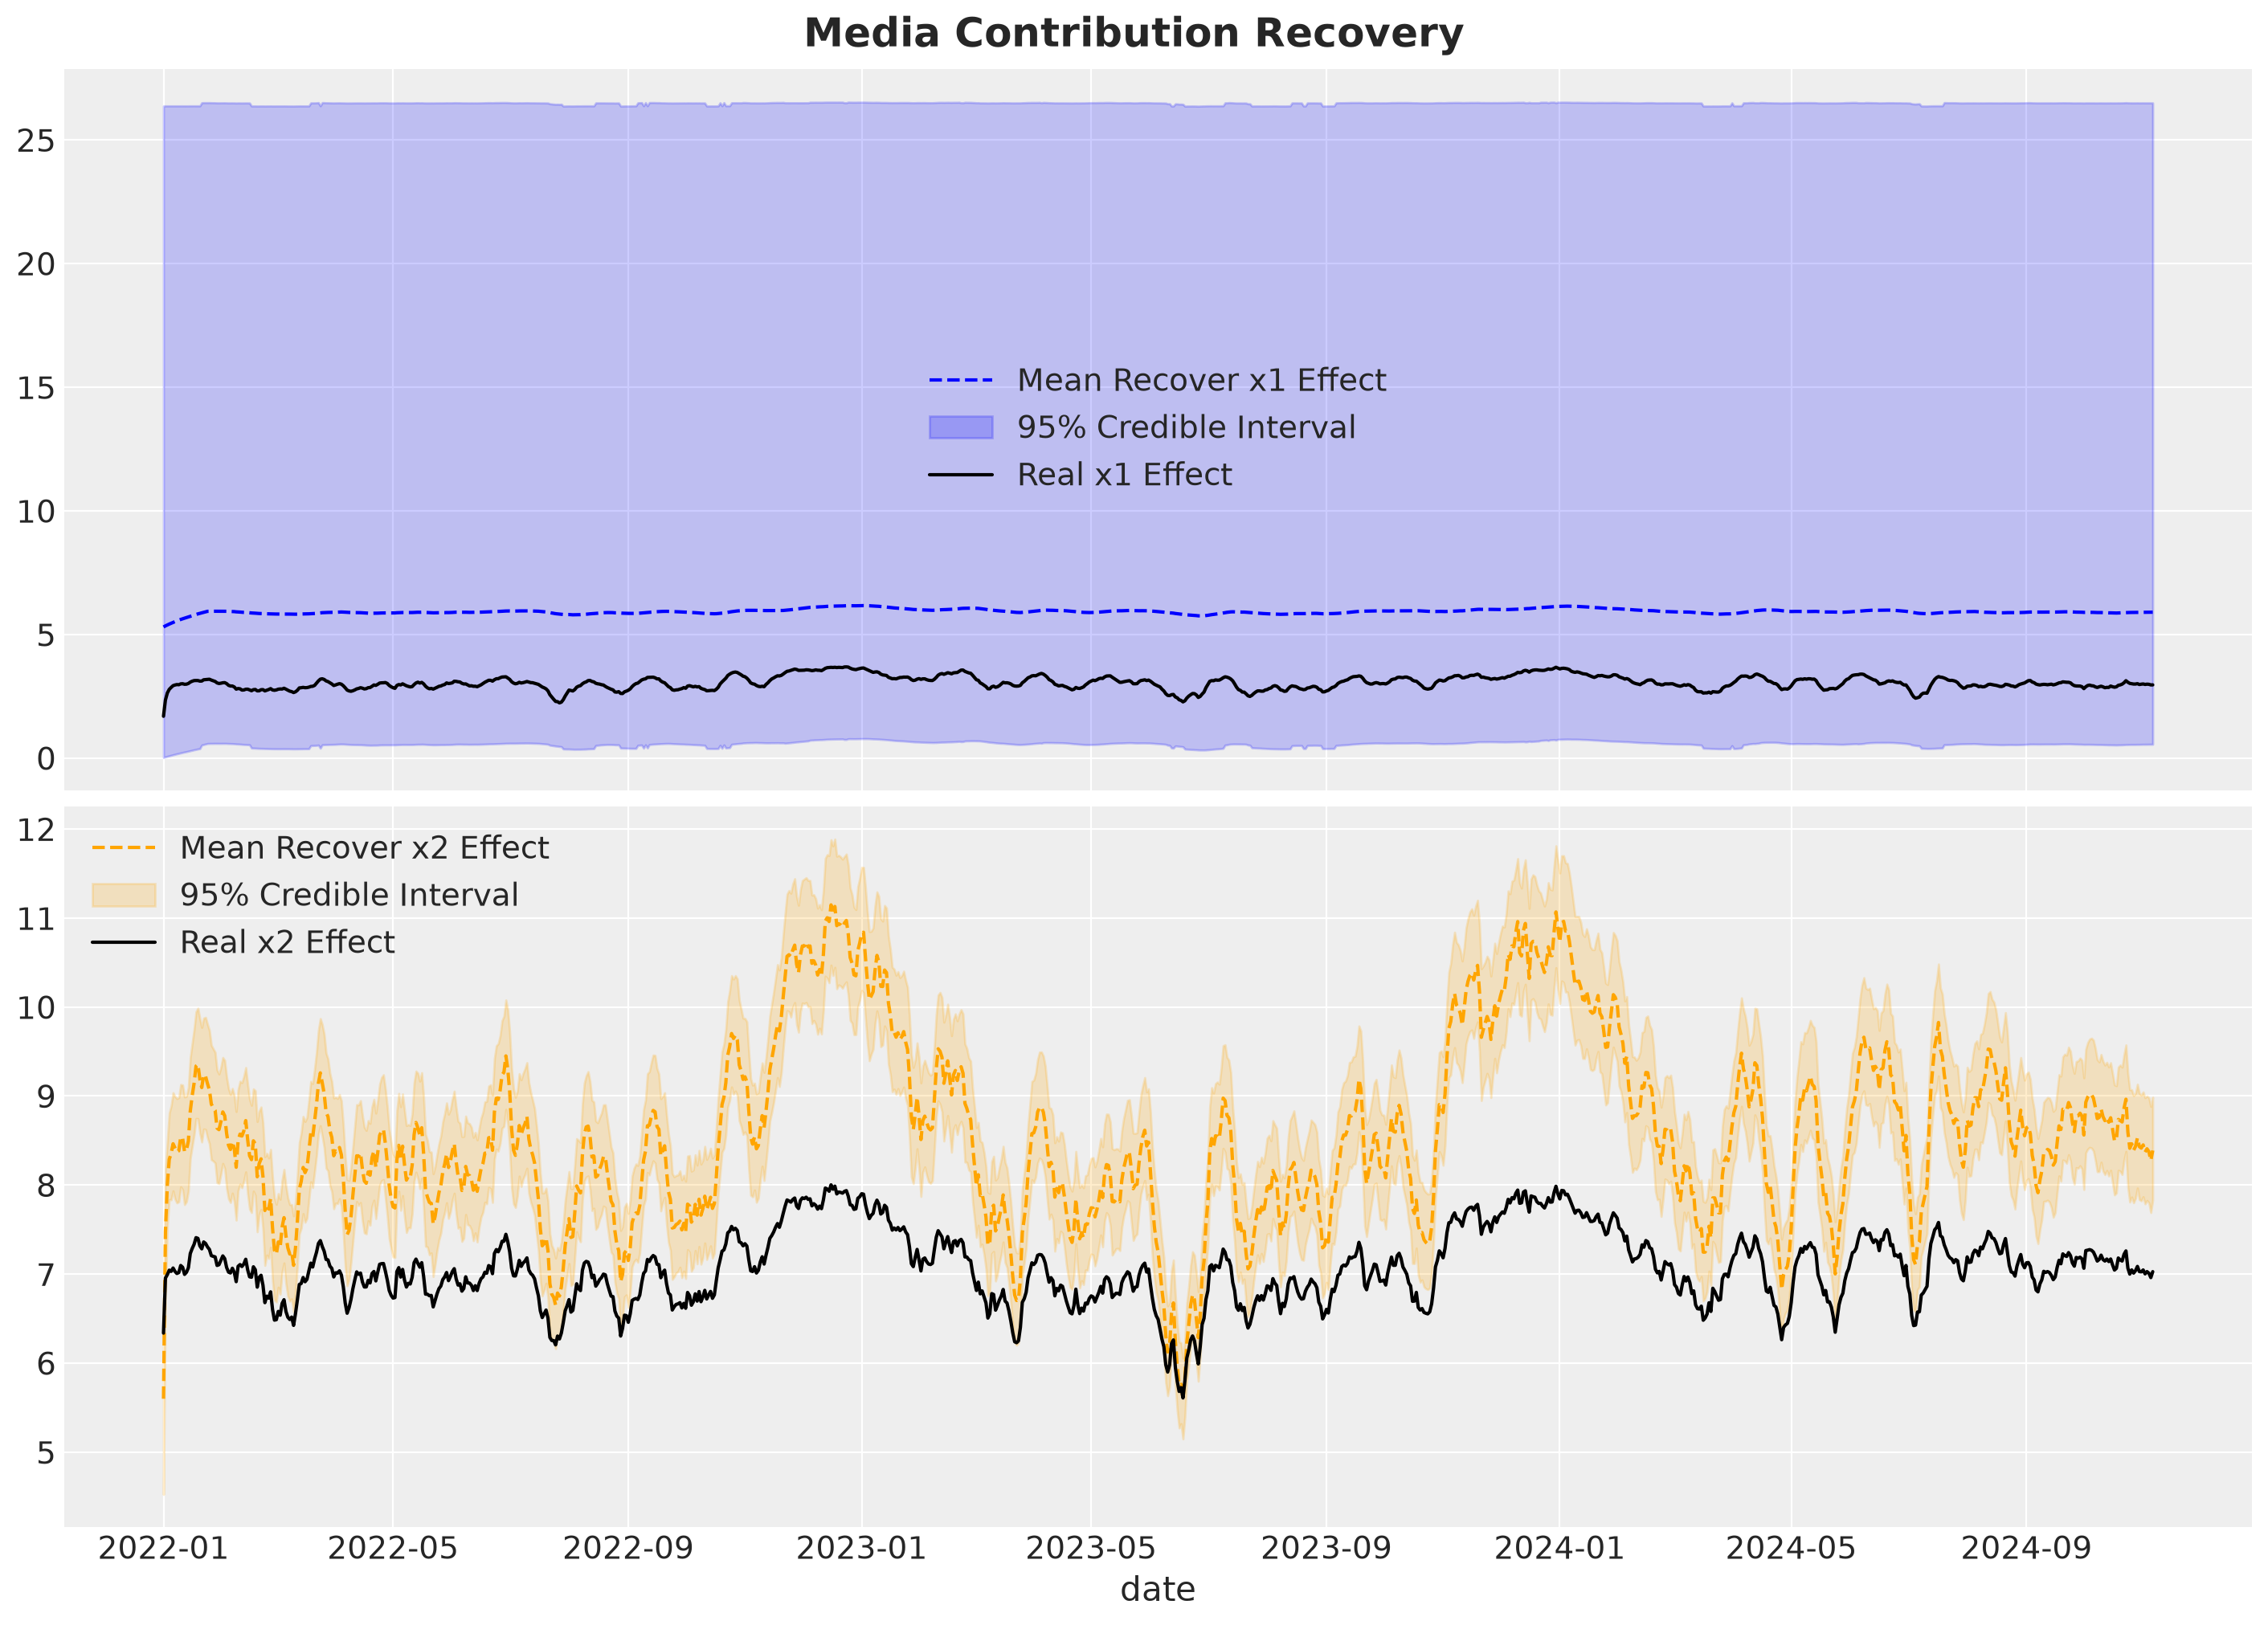

In [32]:
initial_model_recover_effect = az.hdi(
    naive_causal_mmm_v2.fit_result["channel_contribution_original_scale"], prob=0.95
)
initial_model_mean_effect = naive_causal_mmm_v2.fit_result[
    "channel_contribution_original_scale"
].mean(dim=["chain", "draw"])
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
# Social media
ax[0].plot(
    date_range,
    initial_model_mean_effect.sel(channel="x1"),
    label="Mean Recover x1 Effect",
    linestyle="--",
    color="blue",
)
ax[0].fill_between(
    date_range,
    initial_model_recover_effect.sel(ci_bound="lower").sel(channel="x1"),
    initial_model_recover_effect.sel(ci_bound="upper").sel(channel="x1"),
    alpha=0.2,
    label="95% Credible Interval",
    color="blue",
)
ax[0].plot(
    date_range, df["x1_adstock_saturated"], label="Real x1 Effect", color="black"
)
# google
ax[1].plot(
    date_range,
    initial_model_mean_effect.sel(channel="x2"),
    label="Mean Recover x2 Effect",
    linestyle="--",
    color="orange",
)
ax[1].fill_between(
    date_range,
    initial_model_recover_effect.sel(ci_bound="lower").sel(channel="x2"),
    initial_model_recover_effect.sel(ci_bound="upper").sel(channel="x2"),
    alpha=0.2,
    label="95% Credible Interval",
    color="orange",
)
ax[1].plot(
    date_range, df["x2_adstock_saturated"], label="Real x2 Effect", color="black"
)
# formatting
ax[0].legend()
ax[1].legend()
plt.grid(True)
ax[1].set(xlabel="date")
fig.suptitle("Media Contribution Recovery", fontsize=18, fontweight="bold");

At this point, we might feel like we have lost everything. It may seem that some kind of bad luck is affecting our data. Or, we could have an unknown factor that is influencing our marketing results without our notice. 

After some reflection, we can consider that our competitors’ actions, like their offers and discounts, could be impacting our marketing results. In other words, when our competitors spend more on marketing, they can take away some of our potential incremental sales. Even if we spend the same amount to get exposure, aggressive competitor offers can pull customers away from us as they buy other products instead.

Will this affect all our channels the same way? Probably not. Our competitors may not impact our brand awareness, but they likely influence our customers’ consideration. We might think that $x2$ is more affected by our competitors than $x1$. This is because $x2$ is closer to the purchase decision, while $x1$ relates more to brand exposure.

This suggests that ‘competitor_offers’ might be an unseen factor affecting $x2$ but not $x1$. Formally, this means we could express $x2$ as a function of ‘competitor_offers’ while $x1$ would not include this factor.

$$
x2 = f(competitor\_offers) + f(x1) + f(Spend_{x2}) + f(holiday\_signal) + \epsilon
$$

$$
x1 = f(Spend_{x1}) + f(holiday\_signal) + \epsilon
$$

This is a good approach for building our model. However, we need to add ‘competitor_offers’ to our model, and we currently have no data on our competitors, so we need to think creatively.

### Using Gaussian Process to Model Competitor Offers

Since we do not directly observe competitor activities like offers or discounts, `competitor_offers` remains an **unmeasured confounder** of $x2$ and the outcome. A **Gaussian Process (GP)** can provide a flexible time-varying component that may act as a proxy for some latent temporal structure. This is a modeling assumption: it does not observe `competitor_offers` or, by itself, close the backdoor path in the DAG.

A Gaussian Process can be expressed as:

$$
f(t) \sim \mathcal{GP}(m(t), k(t, t'))
$$

Where:
- $f(t)$: The hidden function representing ‘competitor_offers’ over time.
- $m(t)$: The mean function, often set to 0 unless we have prior knowledge of a specific trend.
- $k(t, t')$: The covariance function (or kernel), which determines the smoothness and structure of $f(t)$.

PyMC-Marketing includes Gaussian Processes, using a **Hilbert Space Gaussian Process (HSGP) approximation** to make calculations more manageable. This allows us to approximate the hidden function $f(t)$ efficiently.

#### Why Use a Gaussian Process?

1. Reveal the hidden structure of ‘competitor_offers’ and other unobserved variables based on its connections to $x2$ and other observed variables.
2. Capture non-linear, varying effects that may arise from unseen competitor activities.

Now let's see how we can implement this in PyMC-Marketing!

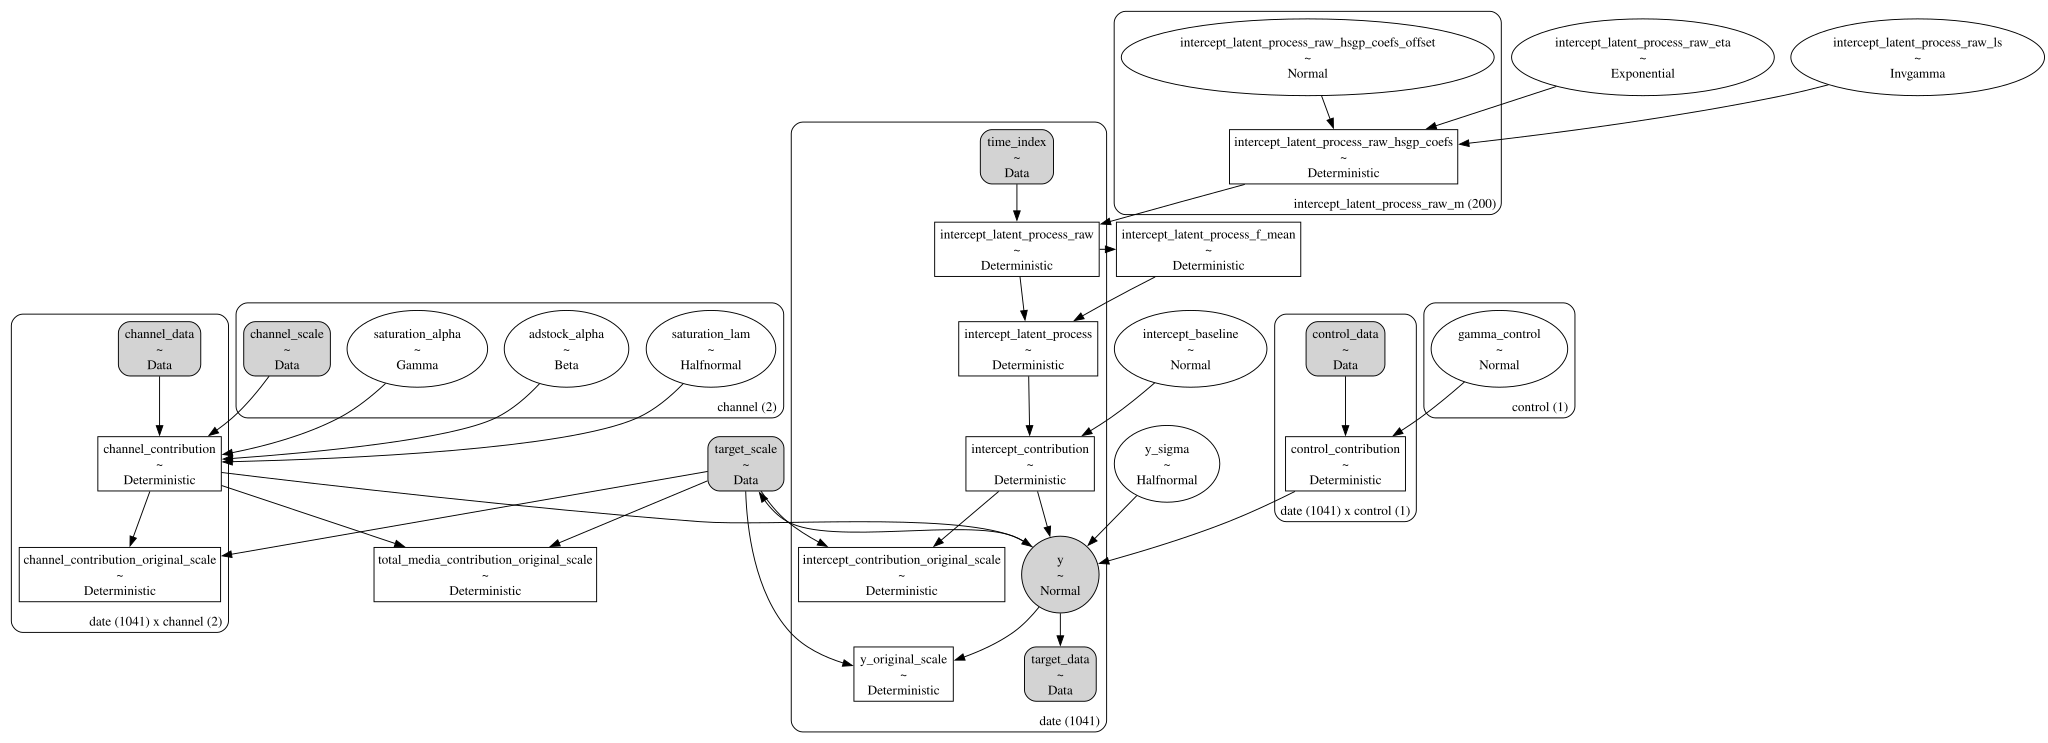

In [33]:
causal_dag = """
digraph {
    x1 -> y;
    x2 -> y;
    x1 -> x2;
    holiday_signal -> y;
    holiday_signal -> x1;
    holiday_signal -> x2;
    competitor_offers -> x2;
    competitor_offers -> y;
    market_growth -> y;
}
"""

causal_mmm = MMM(
    sampler_config=sample_kwargs,
    target_column="y",
    date_column="date_week",
    adstock=GeometricAdstock(l_max=24),
    saturation=MichaelisMentenSaturation(),
    channel_columns=["x1", "x2"],
    control_columns=["holiday_signal"],
    # Define the outcome node and the causal DAG
    outcome_node="y",
    dag=causal_dag,
    # Time varying intercept to account for the unobserved confounder
    time_varying_intercept=True,
    model_config={
        "intercept": Prior("Normal", mu=1, sigma=2),
        "intercept_tvp_config": HSGPKwargs(
            m=200,
            L=None,
            eta_lam=1.0,
            ls_mu=2.0,
            ls_sigma=10.0,
            cov_func=CovFunc.Matern52,
        ),  # 2. Pass the config here
    },
)

causal_mmm.build_model(X=X, y=y)
causal_mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "intercept_contribution",
        "y",
    ]
)

pm.model_to_graphviz(causal_mmm.model)

In [34]:
(
    causal_mmm.causal_graphical_model.adjustment_set,
    causal_mmm.causal_graphical_model.minimal_adjustment_set,
    causal_mmm.causal_graphical_model.is_backdoor_identified,
)

(['competitor_offers', 'holiday_signal'], None, False)

Let’s delve into the output. The graph-level `adjustment_set` requires both `competitor_offers` and `holiday_signal`. However, `competitor_offers` is not among the variables supplied to the model, so `minimal_adjustment_set` is `None` and `is_backdoor_identified` is `False`. The observed variables therefore do not close the backdoor path from `x2` through competitor activity. We set `time_varying_intercept=True` as a flexible proxy for unmeasured time-varying structure, not as proof that the competitor path has been identified.

Now, let’s take a look at how well our model fits.

In [35]:
X = data.drop("y", axis=1)
y = data["y"]

In [36]:
causal_mmm.fit(X=X, y=y, target_accept=0.97, random_seed=rng)
causal_mmm.sample_posterior_predictive(
    X, extend_idata=True, combined=True, random_seed=rng
)

NUTS[nutpie]: [y_sigma, gamma_control, adstock_alpha, saturation_lam, saturation_alpha, intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline]


Output()

Output()

Sampling: [y]


Output()

<xarray.Dataset> Size: 83MB
Dimensions:           (date: 1041, sample: 5000)
Coordinates:
  * date              (date) datetime64[us] 8kB 2022-01-01 ... 2024-11-06
  * sample            (sample) object 40kB MultiIndex
  * chain             (sample) int64 40kB 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9
  * draw              (sample) int64 40kB 0 1 2 3 4 5 ... 495 496 497 498 499
Data variables:
    y                 (date, sample) float64 42MB 0.5952 0.5945 ... 0.7959 0.797
    y_original_scale  (date, sample) float64 42MB 8.426 8.417 ... 11.27 11.28
Attributes:
    created_at:                 2026-09-19T04:51:03.255603+00:00
    creation_library:           ArviZ
    creation_library_version:   1.2.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  6.2.0
    sample_dims:                ['sample']

In [37]:
# show divergencies
causal_mmm.idata["sample_stats"]["diverging"].sum().item()

Great compared to the previous models, we don't have any divergencies, as we discussed before thats a good signal 🔥. 

Lets observe the recovered effect of our treatment variables ($x1$ and $x2$) and as usual the not so causal model fit 👀

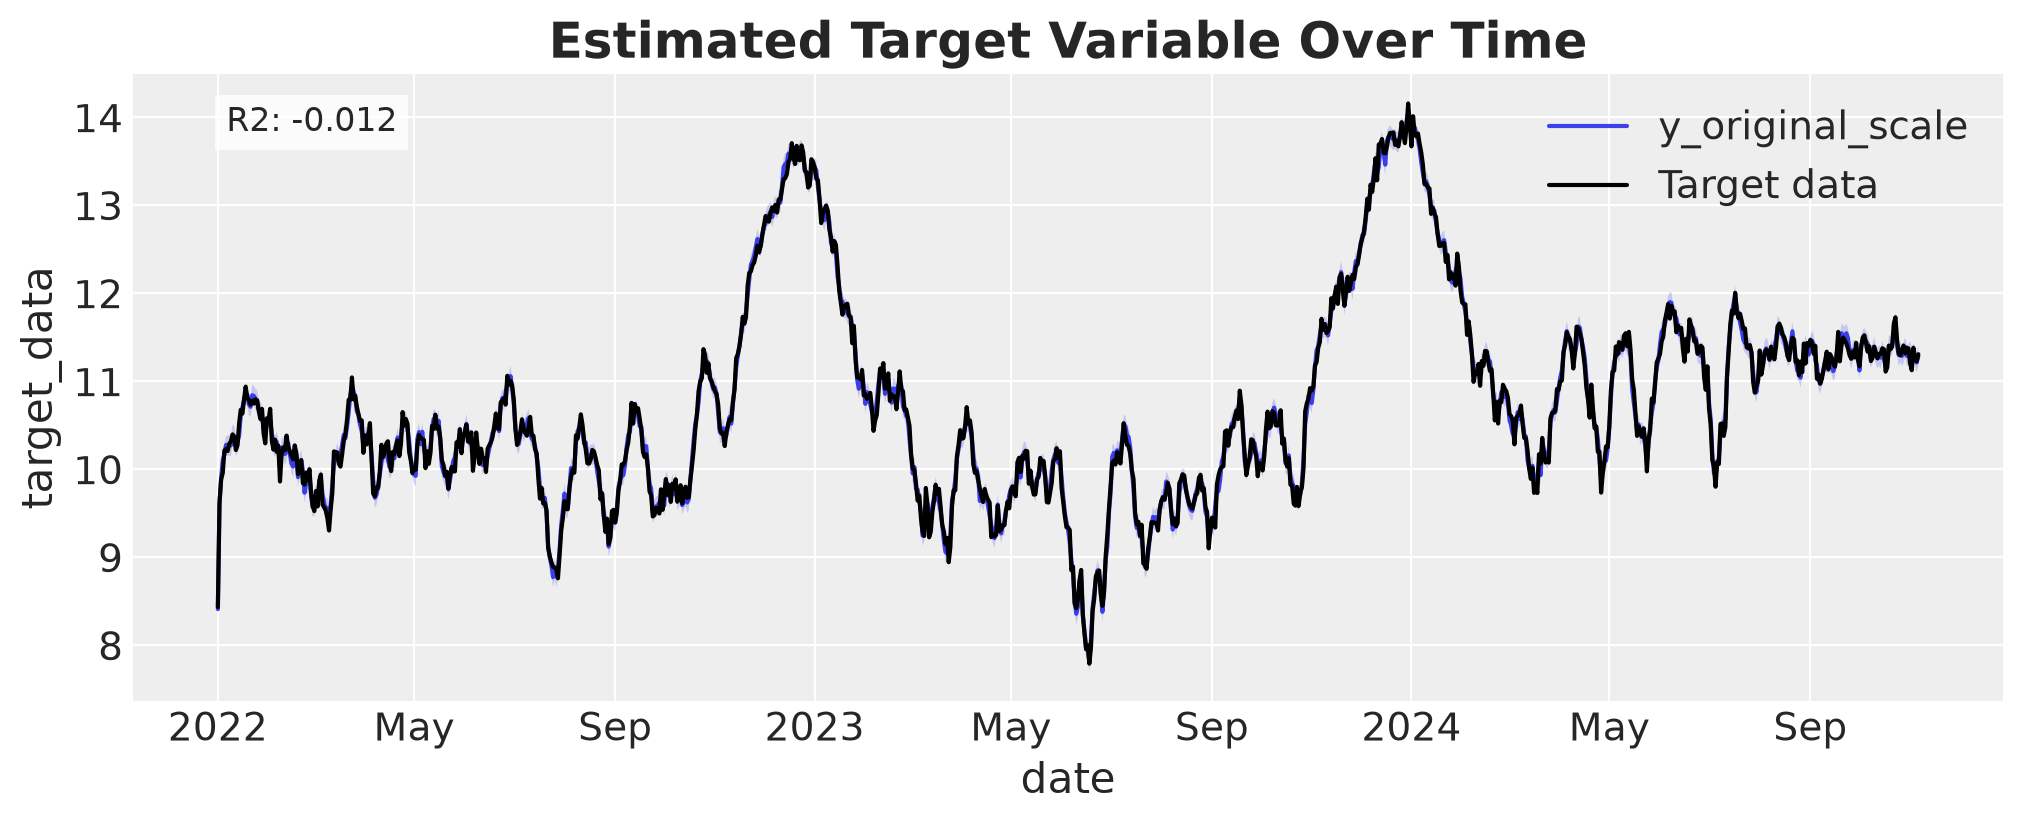

In [38]:
r2 = bayesian_r2(causal_mmm.idata, pred_mean="y_original_scale")[0]
fig, ax = causal_mmm.plot.posterior_predictive(var=["y_original_scale"])
ax = ax.flatten()
causal_mmm.idata.constant_data.target_data.plot(
    label="Target data",
    color="black",
    ax=ax[0],
)
ax[0].text(
    0.05,
    0.95,
    f"R2: {r2:.3f}",
    transform=ax[0].transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
)
ax[0].legend()
ax[0].set_title("Estimated Target Variable Over Time", fontsize=18, fontweight="bold");

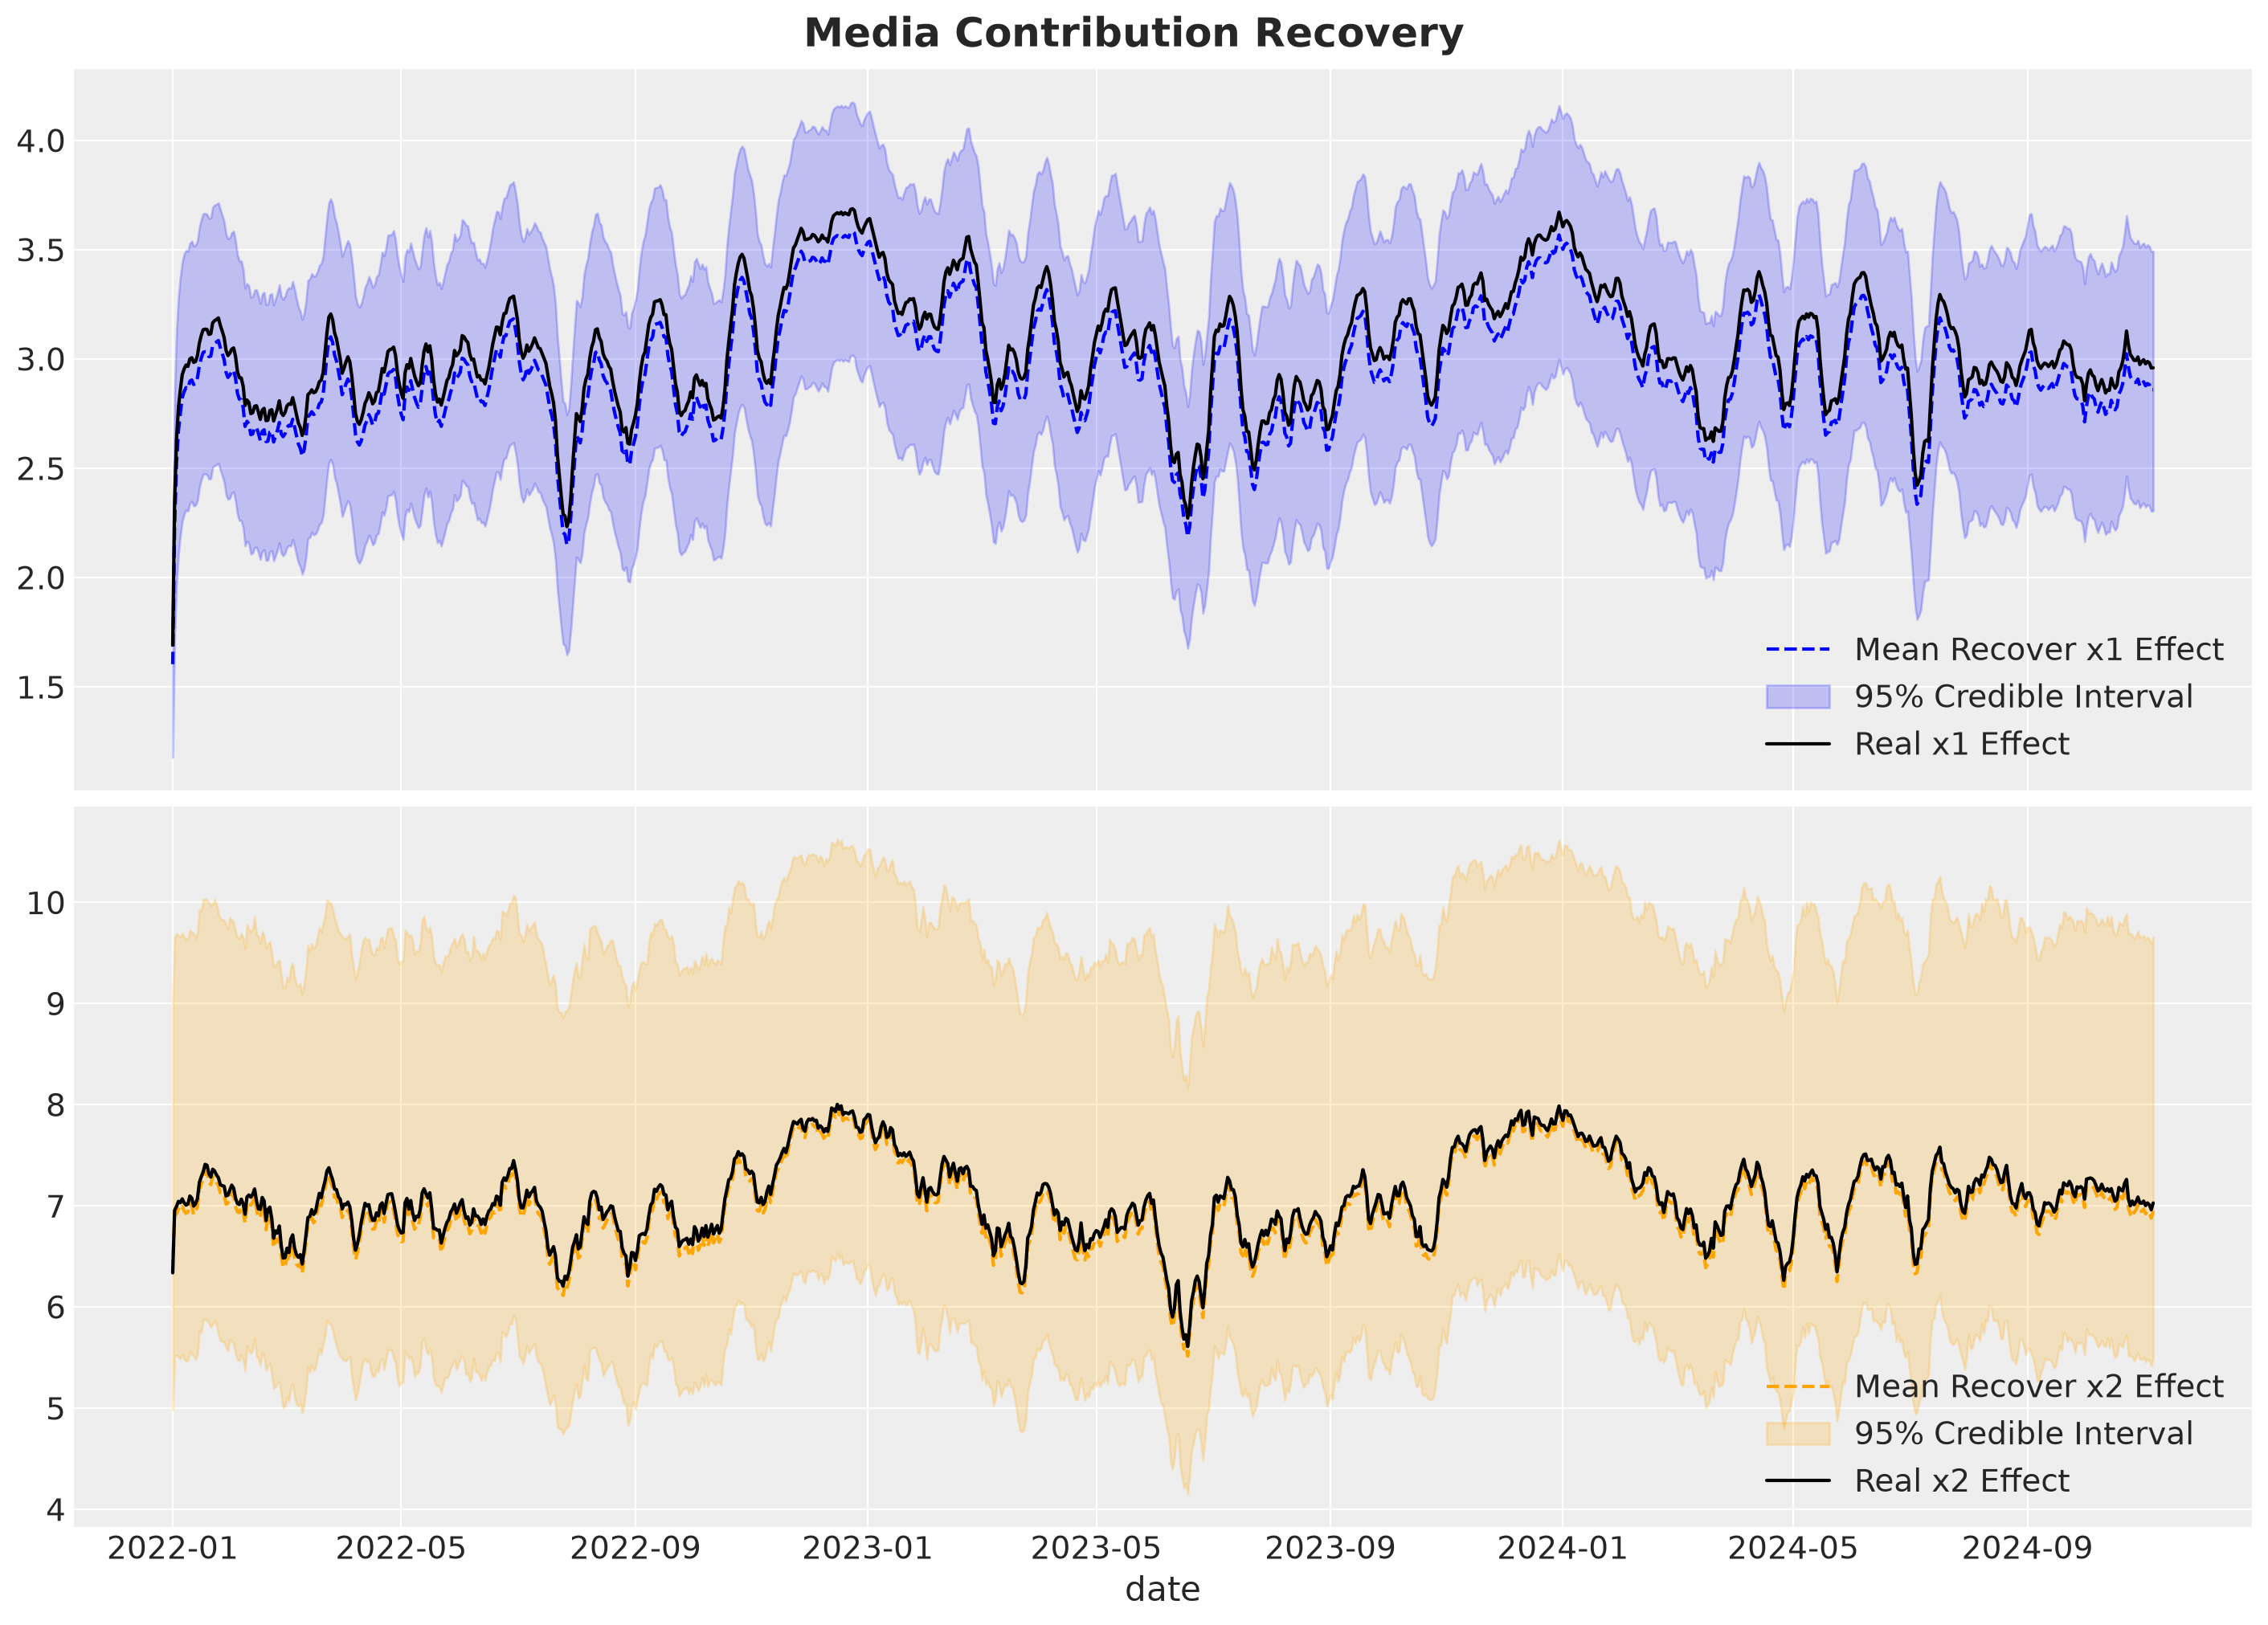

In [39]:
initial_model_recover_effect = az.hdi(
    causal_mmm.fit_result["channel_contribution_original_scale"], prob=0.95
)
initial_model_mean_effect = causal_mmm.fit_result[
    "channel_contribution_original_scale"
].mean(dim=["chain", "draw"])
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
# Social media
ax[0].plot(
    date_range,
    initial_model_mean_effect.sel(channel="x1"),
    label="Mean Recover x1 Effect",
    linestyle="--",
    color="blue",
)
ax[0].fill_between(
    date_range,
    initial_model_recover_effect.sel(ci_bound="lower").sel(channel="x1"),
    initial_model_recover_effect.sel(ci_bound="upper").sel(channel="x1"),
    alpha=0.2,
    label="95% Credible Interval",
    color="blue",
)
ax[0].plot(
    date_range, df["x1_adstock_saturated"], label="Real x1 Effect", color="black"
)
# google
ax[1].plot(
    date_range,
    initial_model_mean_effect.sel(channel="x2"),
    label="Mean Recover x2 Effect",
    linestyle="--",
    color="orange",
)
ax[1].fill_between(
    date_range,
    initial_model_recover_effect.sel(ci_bound="lower").sel(channel="x2"),
    initial_model_recover_effect.sel(ci_bound="upper").sel(channel="x2"),
    alpha=0.2,
    label="95% Credible Interval",
    color="orange",
)
ax[1].plot(
    date_range, df["x2_adstock_saturated"], label="Real x2 Effect", color="black"
)
# formatting
ax[0].legend()
ax[1].legend()
plt.grid(True)
ax[1].set(xlabel="date")
fig.suptitle("Media Contribution Recovery", fontsize=18, fontweight="bold");

The fitted model can still describe the observed outcome and recover useful temporal structure, but this fit does not establish that the treatment effects are causally identified. The unmeasured `competitor_offers` path remains an explicit limitation even though holidays are observed and the model includes a time-varying component.

You might have noticed we have variables like market growth that aren’t in the data—what's going on with that? Before diving in, let’s observe the time-varying intercept.

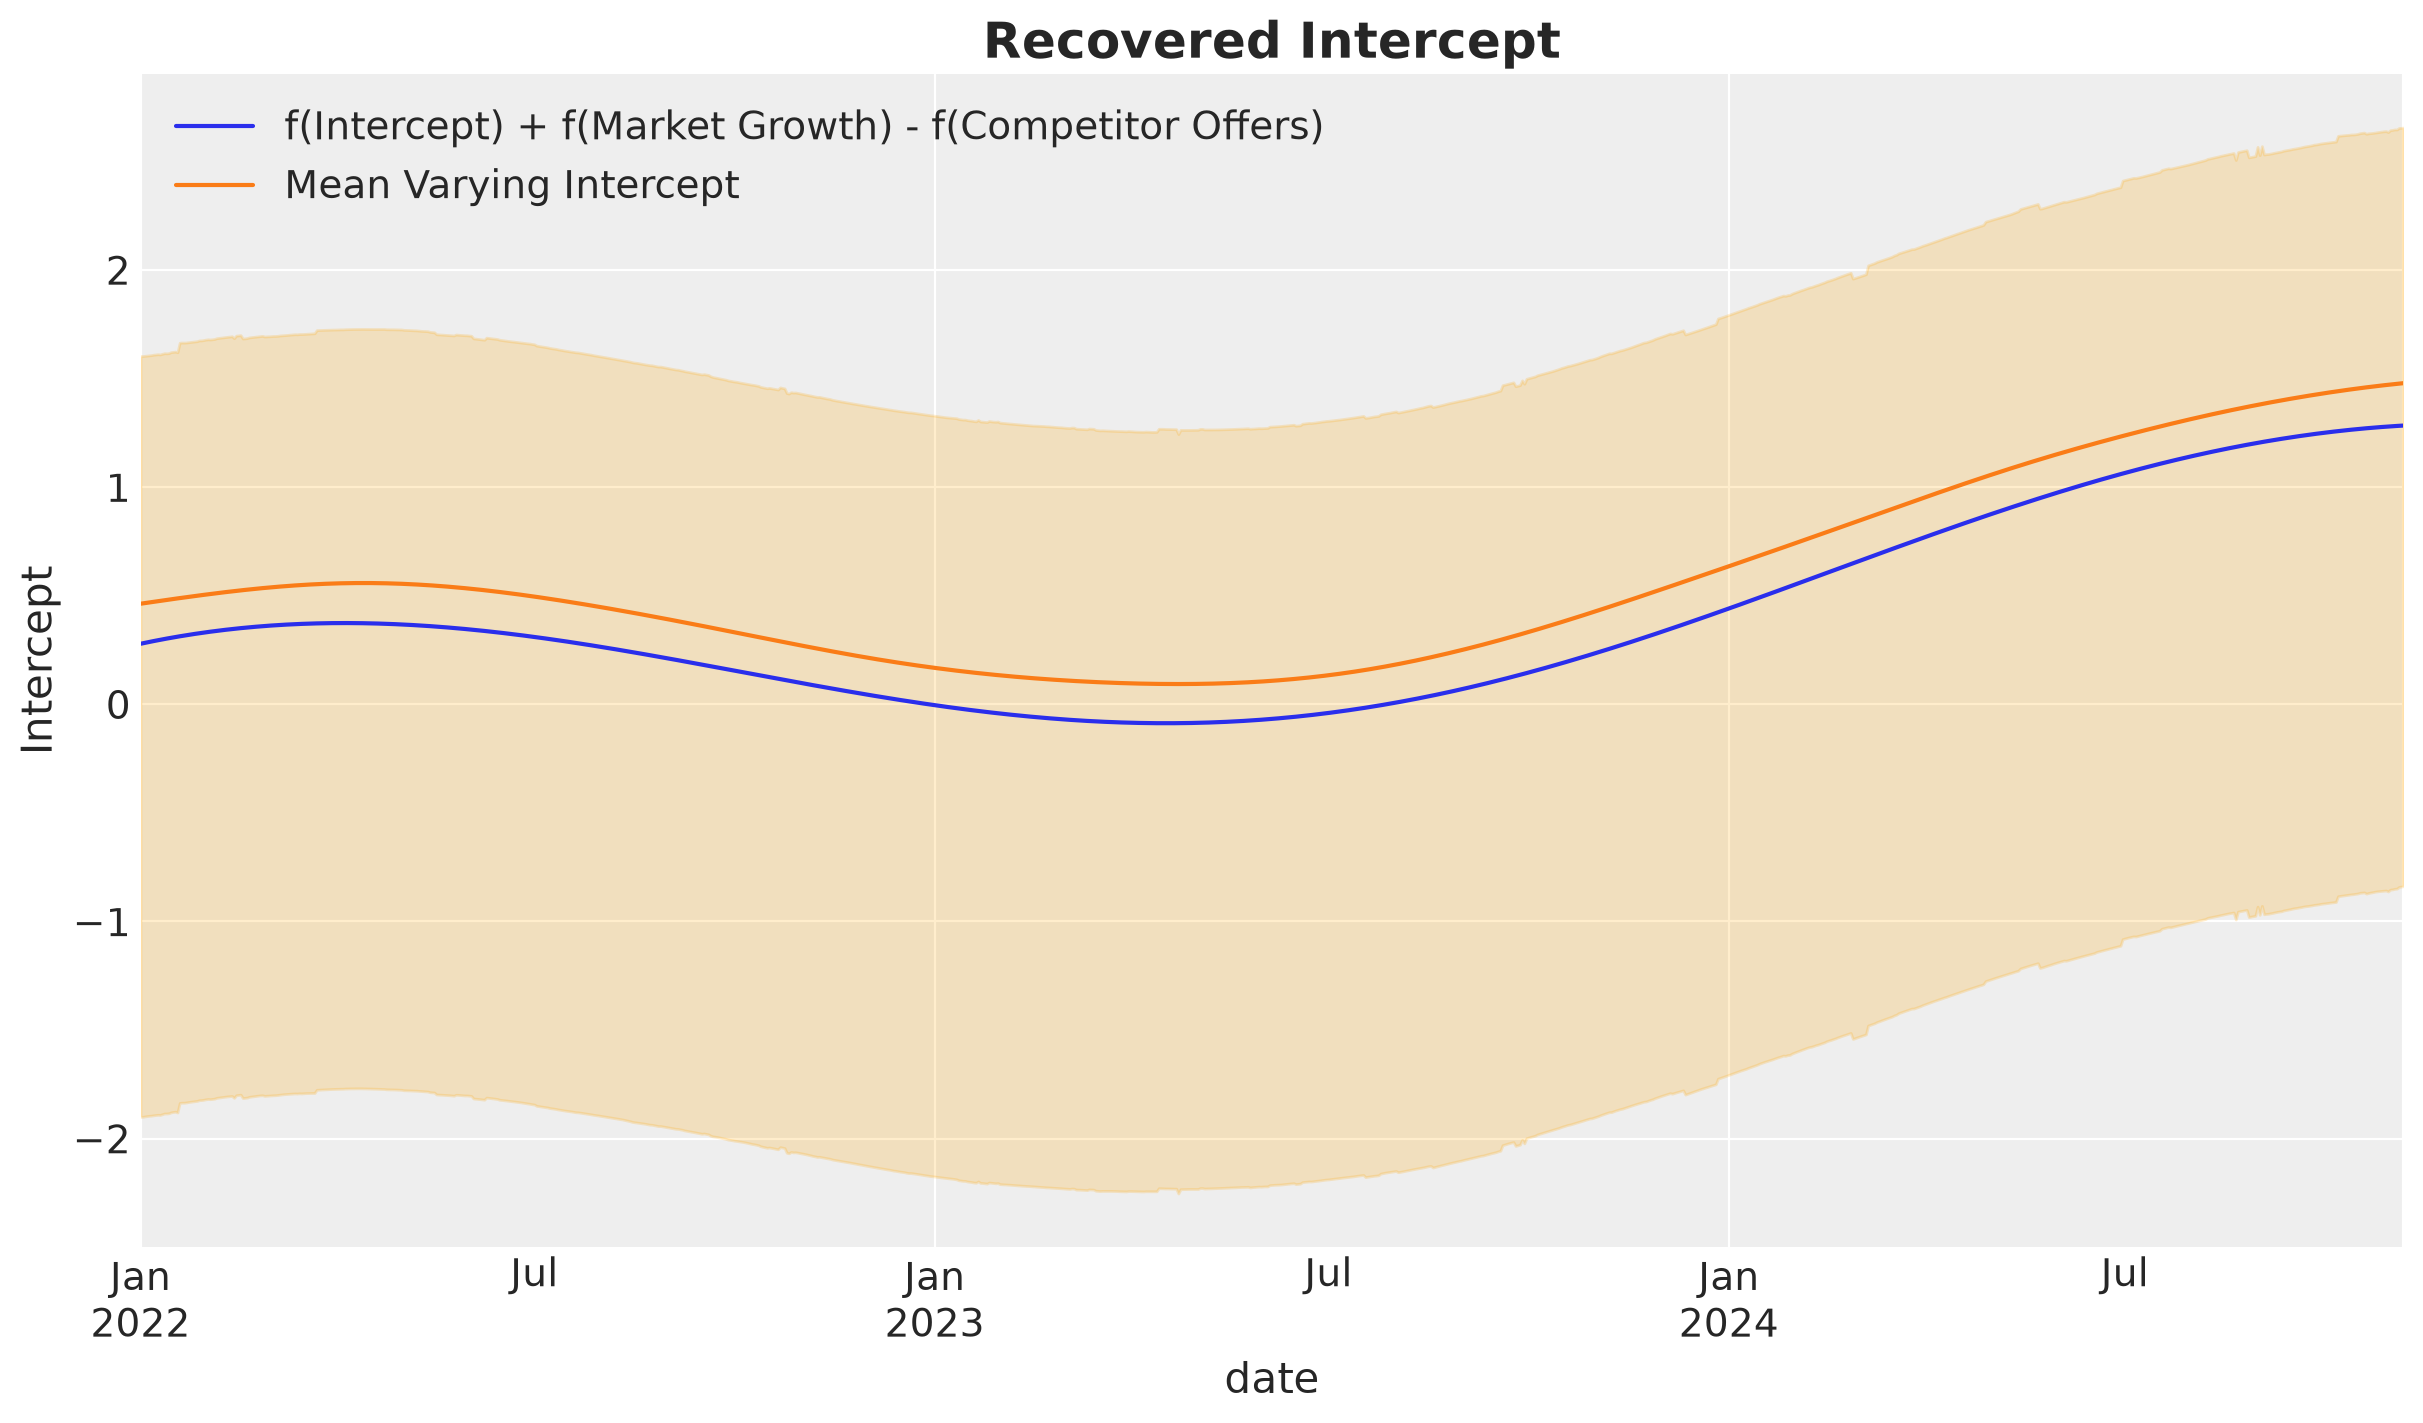

In [40]:
intercept_effect = az.hdi(
    causal_mmm.fit_result["intercept_contribution_original_scale"], prob=0.95
)
mean_intercept = causal_mmm.fit_result["intercept_contribution_original_scale"].mean(
    dim=["chain", "draw"]
)
fig, ax = plt.subplots()
(df.set_index("date_week").eval("f = intercept + market_growth - competitor_offers"))[
    "f"
].plot(ax=ax, label="f(Intercept) + f(Market Growth) - f(Competitor Offers)")
sns.lineplot(x=date_range, y=mean_intercept, label="Mean Varying Intercept")
ax.fill_between(
    date_range,
    intercept_effect.sel(ci_bound="lower"),
    intercept_effect.sel(ci_bound="upper"),
    alpha=0.2,
    label="95% Credible Interval",
    color="orange",
)
ax.set(xlabel="date", ylabel="Intercept")
ax.set_title("Recovered Intercept", fontsize=18, fontweight="bold");

The time-varying intercept tracks temporal variation that is consistent with the combined simulated effects shown above. It cannot tell us which portion is specifically `competitor_offers`, market growth, or another omitted time-varying cause without stronger assumptions or measurements. It should therefore be interpreted as a proxy for latent temporal structure, not as identification of the hidden confounder.

Since we have a solid grasp of our context, we can identify which variables our Gaussian process is figuring out. This insight helps us fine-tune our model. On the flip side, if we didn’t understand our world well, the Gaussian process might be inferring the wrong variables, leading to incorrect conclusions. That’s why it’s crucial to really understand our causal ecosystem, the world around us, and how our causal relationships are structured. Every choice and assumption we make with our models can complicate things, impacting the accuracy of our results. 

We shouldn’t complicate our model without a solid reason. Adding new variables or Gaussian processes should be carefully considered! It’s essential to grasp the consequences of our choices and the assumptions we adopt once we make them. Using causal identification techniques can help us figure out which control variables to include, guiding us in the causal discovery journey. 

## Wrap-Up

In this notebook, we explored how causal graphs can expose unobserved confounding and how valid adjustment sets guide the choice of controls. We also used a Gaussian-process time-varying intercept to model latent temporal structure while keeping the remaining identification limitation explicit.

Now it’s your turn—go ahead and start building your own models!

## References

- [DoWhy](https://github.com/microsoft/dowhy)
- [CausalPy](https://causalpy.readthedocs.io/en/stable/)
- [Aleksander Molak - Causal Discovery](https://www.amazon.com/Causal-Inference-Discovery-Python-learning/dp/1804612987)
- [Judea Pearl - The book of why](https://www.amazon.com/Book-Why-Science-Cause-Effect/dp/046509760X)
- [Bridging Causal Thinking and Media Mix Models: Carlos Trujillo & Ben Vincent](https://colab.research.google.com/drive/1r5pi9Lh_A6h_CKQFEjyn-7iykL8x-X_H#scrollTo=DRFEJyK1VCi3)

In [41]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Fri, 18 Sep 2026

Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pytensor      : 3.2.4

IPython       : 9.15.0
arviz         : 1.2.0
arviz_stats   : 1.2.0
graphviz      : 0.21
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 3.0.5
preliz        : 0.27.1
pymc          : 6.2.0
pymc_extras   : 0.14.0
pymc_marketing: 1.1.0
seaborn       : 0.13.2

Watermark: 2.6.0

